In [1]:
# R-802 Methanol Reactor Design | Cell 1: stream 804 and operating conditions
# Fresh syngas flow rates EXCLUDE the H2S addition; units are kg/h.
FRESH_FEED_KG_H = {
    "H2": 2505.43, "CO": 15905.0, "CO2": 1136.0,
    "CH3OH": 0.0, "H2O": 0.0, "N2": 37.0, "CH4": 676.0,
    "C2H2": 12.0, "C2H4": 146.0, "C2H6": 1.0, "C6H6": 1.0,
}
CONDITIONS = {
    # raw_temperature_C is the upstream raw gas temperature; H-801 heats it to 180 C.
    "raw_temperature_C": 40.0, "raw_pressure_bar_abs": 48.96,
    "raw_h2s_mass_fraction": 0.0003,  # 0.03 mass%, inclusive of H2S
    "raw_h2s_mole_fraction_alternative": 0.0001,  # rounded alternative, NOT applied simultaneously
    "guard_outlet_h2s_ppmv": 0.01,  # fresh-feed ZnO guard outlet (assumed)
    "reactor_inlet_temperature_C": 210.0, "reactor_inlet_pressure_bar_abs": 48.96,
    "coolant_temperature_C": 235.0,
}


In [2]:
# Cell 2: reactor geometry and heat removal. Geometry is a preliminary assumption.
REACTOR = {
    "number_of_tubes": 4000, "tube_inside_diameter_m": 0.040,
    "bed_length_m": 9.0, "bed_void_fraction": 0.285,
    "wall_thickness_m": 0.002, "steel_grade": "316L",
    "steel_conductivity_override_W_m_K": None,  # None uses Alleima's temperature table
    "inside_fouling_m2_K_W": 0.0001, "outside_fouling_m2_K_W": 0.0001,
    "water_surface_roughness_um": 1.0, "radial_Peclet_number": 8.0,
    "coolant_inlet_quality": 0.0, "coolant_exit_quality": 0.10,
    "cooling_duty_margin_fraction": 0.15,
    "catalyst_screen_temperature_C": 300.0,  # literature screen, not sharp damage onset
    "thermal_margin_K": 20.0, "max_pressure_drop_bar": 1.0,
}


In [3]:
# Cell 3: catalyst. Constant activity; no ageing or deactivation is modelled.
CATALYST = {
    "pellet_diameter_m": 0.0057, "apparent_density_kg_m3": 1140.0,
    "pore_fraction": 0.44, "tortuosity": 3.54, "pore_diameter_m": 10e-9,
    "pellet_conductivity_W_m_K": 0.454,
    "fresh_intrinsic_activity": 1.0, "kinetic_model": "bisotti_2021",
    "eos": "SRK",
}


In [4]:
# Cell 4: D-801 separator, splitter and recycle; the purge fraction is a specified design choice.
LOOP = {
    "purge_fraction": 0.065, "flash_temperature_C": 32.0,
    "post_reactor_pressure_drop_bar": 0.50,
    "H801_hot_pressure_drop_bar": 0.20,
    "compressor_isentropic_efficiency": 0.75,
    "H801_cold_outlet_temperature_C": 180.0,
    "guard_temperature_C": 250.0,
    "H801_minimum_approach_K": 10.0,
    "methanol_target_kg_h": 15432.0,
    "reactor_h2s_screen_ppmv": 0.010,
}


Run the cells in order. The recycle-loop solve takes about 3 minutes. Requires NumPy, SciPy, Matplotlib and IPython.

In [5]:
# Internal reference data, source correlations and methods are in this cell.
# All user-settable case inputs appear in cells 1–4 above.
from __future__ import annotations
import math
from copy import deepcopy
import numpy as np
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import least_squares, minimize, minimize_scalar, brentq
from numpy.polynomial.legendre import leggauss

INPUTS = {
    "feed_kg_h": {                   # Uploaded stream 801, EXCLUDING H2S
        "H2": 2505.43, "CO": 15905.0, "CO2": 1136.0,
        "CH3OH": 0.0, "H2O": 0.0, "N2": 37.0, "CH4": 676.0,
        "C2H2": 12.0, "C2H4": 146.0, "C2H6": 1.0, "C6H6": 1.0,
    },
    "raw_temperature_C": 40.0,
    "raw_pressure_bar": 48.96,       # Assumed ABSOLUTE; confirm stream basis
    "h2s_basis": "mass_fraction",   # Or "mole_fraction"; do not impose both
    "raw_h2s_mass_fraction": 0.0003, # 0.03 MASS %, inclusive total denominator
    "raw_h2s_mole_fraction": 0.0001, # 0.01 MOLE %, alternative rounded datum
    "apply_ZnO_guard": True,
    "guard_outlet_h2s_ppmv": 0.01,    # USER specification at fresh-feed guard, not at reactor
    "reactor_temperature_C": 210.0, # NEW worked loop case; AFTER H803
    "reactor_pressure_bar": 48.96,  # Before packed bed; upstream losses not given
    "coolant_temperature_C": 235.0, # NEW worked loop case; constant boiling-water T
    "number_of_tubes": 4000,        # NEW assumed size for recycle; original was 1000
    "tube_inside_diameter_m": 0.040,
    "bed_length_m": 9.0,
    "pellet_diameter_m": 0.0054,     # Equivalent spherical diameter for Ergun
    "bed_void_fraction": 0.285,
    "pellet_apparent_density_kg_m3": 1190.0, # NOT skeletal density
    "catalyst_activity": 1.0,       # Beginning-of-life intrinsic activity for this run
    "kinetic_model": "bisotti_2021", # Also "graaf_1990" for model sensitivity
    "eos": "SRK",                  # "PR" and "IDEAL" are sensitivity alternatives
    "binary_interactions": {},     # e.g. {"H2,CO2": value}; unprovided kij = 0
    "viscosity_multiplier": 1.0,    # Gas viscosity estimate; use for uncertainty study
    "max_temperature_C": 280.0,     # Assumed screening constraint; verify with catalyst supplier
    "max_pressure_drop_bar": 1.0,   # Assumed screening constraint, not a universal standard
    "rtol": 2e-6,
    "profile_points": 251,
    "scan": {                      # Optional, not run by this notebook
        "inlet_temperature_C": [210.0, 220.0, 230.0, 240.0, 250.0],
        "coolant_temperature_C": [200.0, 210.0, 220.0, 230.0, 240.0],
        "inlet_pressure_bar": [42, 48.96, 54]
    }
}
# =======================================================================
# ======================== EDIT LOOP INPUTS HERE =========================
LOOP_INPUTS = {
    "reactor_overrides": {},  # Optional JSON/API overrides of INPUTS above
    "initial_recycle_kg_h": {
        "H2": 5041.0, "N2": 867.0, "CO2": 8201.0, "CO": 15481.0,
        "CH4": 14982.0, "H2O": 3.0, "C2H2": 145.0, "C2H4": 2468.0,
        "C2H6": 10.0, "CH3OH": 840.0, "C6H6": 0.0, "H2S": 0.0,
    },
    "initial_purge_kg_h": 2001.0,
    "purge_fraction": 0.065,  # Worked case. Original estimate gives 0.03998881
    "flash_temperature_C": 32.0,  # ASSUMED D-801 T, using original recycle T
    "post_reactor_pressure_drop_bar": 0.5, # ASSUMED H-801 hot + H-804 + lines
    "H801_hot_pressure_drop_bar": 0.2, # Part of the 0.5 bar above; remainder H804/lines
    "mixer_to_reactor_pressure_drop_bar": 0.0, # Neglected, as in original model
    "compressor_isentropic_efficiency": 0.75,  # ASSUMED
    "H801_cold_outlet_temperature_C": 180.0,  # ASSUMED heat recovery target
    "guard_temperature_C": 250.0,             # ASSUMED R-801 inlet/outlet
    "H801_minimum_approach_K": 10.0,
    "methanol_target_kg_h": 15432.0,   # CH3OH COMPONENT in stream 814
    "reactor_h2s_limit_ppmv": 0.01,
    "max_iterations": 30,              # Maximum nonlinear solver evaluations
    "closure_rtol": 2e-6,
    "closure_atol_mol_s": 1e-6,
    "coarse_purge_fractions": [0.02, 0.04, 0.06, 0.08],
    "coarse_tube_counts": [1000, 2000, 4000, 8000],  # Design alternatives; not hidden changes
    "coarse_operating_pairs_C": [[225.0, 220.0], [240.0, 235.0]], # [Tin, Tcool]
    "liquid_model": "NRTL",           # Or IDEAL for explicit sensitivity
    "liquid_molar_volumes_m3_mol": [41.0e-6, 18.1e-6], # ASSUMED constants
    "nrtl_b12_K": -95.13209282738782,  # Species order: methanol(1), water(2)
    "nrtl_b21_K": 398.95345259688855,  # ChemSep coefficients, tau_ij=b_ij/T
    "nrtl_alpha": 0.2999,
}
# =======================================================================


R = 8.31446261815324  # J/(mol K)
SPECIES = ["H2", "CO", "CO2", "CH3OH", "H2O", "N2", "CH4",
           "C2H2", "C2H4", "C2H6", "C6H6", "H2S"]
I = {s: i for i, s in enumerate(SPECIES)}
# Atomic weights are used consistently so atom and mass balances agree exactly.
ELEMENTS = ["C", "H", "O", "N", "S"]
ATOMIC_MASS = np.array([12.011, 1.008, 15.999, 14.007, 32.06])
COMPONENT_DATA = {'H2': {'composition': {'H': 2}, 'nasa7': [2.34433112, 0.00798052075, -1.9478151e-05, 2.01572094e-08, -7.37611761e-12, -917.935173, 0.683010238], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'TPIS78', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 38.0, 'diameter': 2.92, 'polarizability': 0.79, 'rotational-relaxation': 280.0}, 'critical': {'critical-temperature': 32.98, 'critical-pressure': '1.293e6', 'critical-molar-volume': 0.0642, 'critical-compressibility': 0.303, 'acentric-factor': -0.217, 'source': 'Properties of Gases and Liquids, 5th edition, Poling.'}}, 'CO': {'composition': {'C': 1, 'O': 1}, 'nasa7': [3.57953347, -0.00061035368, 1.01681433e-06, 9.07005884e-10, -9.04424499e-13, -14344.086, 3.50840928], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'TPIS79', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 98.1, 'diameter': 3.65, 'polarizability': 1.95, 'rotational-relaxation': 1.8}, 'critical': {'critical-temperature': 133.4, 'critical-pressure': 3500000.0, 'critical-molar-volume': 0.0931, 'critical-compressibility': 0.294, 'acentric-factor': 0.066}}, 'CO2': {'composition': {'C': 1, 'O': 2}, 'nasa7': [2.35677352, 0.00898459677, -7.12356269e-06, 2.45919022e-09, -1.43699548e-13, -48371.9697, 9.90105222], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L7/88', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 244.0, 'diameter': 3.763, 'polarizability': 2.65, 'rotational-relaxation': 2.1}, 'critical': {'critical-temperature': 304.2, 'critical-pressure': 7390000.0, 'critical-molar-volume': 0.0948, 'critical-compressibility': 0.275, 'acentric-factor': 0.228, 'source': 'The acentric factor is taken from Yaws (2001).'}}, 'CH3OH': {'composition': {'C': 1, 'H': 4, 'O': 1}, 'nasa7': [5.71539582, -0.0152309129, 6.52441155e-05, -7.10806889e-08, 2.61352698e-11, -25642.7656, -1.50409823], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/88', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 481.8, 'diameter': 3.626, 'rotational-relaxation': 1.0, 'note': 'SVE'}, 'critical': {'critical-temperature': 513, 'critical-pressure': 8010000.0, 'critical-molar-volume': 0.1179, 'critical-compressibility': 0.224, 'acentric-factor': 0.556}}, 'H2O': {'composition': {'H': 2, 'O': 1}, 'nasa7': [4.19864056, -0.0020364341, 6.52040211e-06, -5.48797062e-09, 1.77197817e-12, -30293.7267, -0.849032208], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/89', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 572.4, 'diameter': 2.605, 'dipole': 1.844, 'rotational-relaxation': 4.0}, 'critical': {'critical-temperature': 647.096, 'critical-pressure': 22064000.0, 'acentric-factor': 0.3442920843}}, 'N2': {'composition': {'N': 2}, 'nasa7': [3.298677, 0.0014082404, -3.963222e-06, 5.641515e-09, -2.444854e-12, -1020.8999, 3.950372], 'T_min_K': 300.0, 'T_max_K': 1000.0, 'nasa_note': '121286', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 97.53, 'diameter': 3.621, 'polarizability': 1.76, 'rotational-relaxation': 4.0}, 'critical': {'critical-temperature': 126.2, 'critical-pressure': 3390000.0, 'acentric-factor': 0.038, 'source': 'The acentric factor is calculated using the pure fluid saturation data from\nLemmon et al. (2022).'}}, 'CH4': {'composition': {'C': 1, 'H': 4}, 'nasa7': [5.14987613, -0.0136709788, 4.91800599e-05, -4.84743026e-08, 1.66693956e-11, -10246.6476, -4.64130376], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/88', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 141.4, 'diameter': 3.746, 'polarizability': 2.6, 'rotational-relaxation': 13.0}, 'critical': {'critical-temperature': 190.7, 'critical-pressure': 4630000.0, 'critical-molar-volume': 0.0989, 'critical-compressibility': 0.288, 'acentric-factor': 0.011}}, 'C2H2': {'composition': {'C': 2, 'H': 2}, 'nasa7': [0.808681094, 0.0233615629, -3.55171815e-05, 2.80152437e-08, -8.50072974e-12, 26428.9807, 13.9397051], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L1/91', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 209.0, 'diameter': 4.1, 'rotational-relaxation': 2.5}, 'critical': {'critical-temperature': 309.2, 'critical-pressure': 6250000.0, 'critical-molar-volume': 0.1129, 'critical-compressibility': 0.274, 'acentric-factor': 0.19}}, 'C2H4': {'composition': {'C': 2, 'H': 4}, 'nasa7': [3.95920148, -0.00757052247, 5.70990292e-05, -6.91588753e-08, 2.69884373e-11, 5089.77593, 4.09733096], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L1/91', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 280.8, 'diameter': 3.971, 'rotational-relaxation': 1.5}, 'critical': {'critical-temperature': 282.8, 'critical-pressure': 5110000.0, 'critical-molar-volume': 0.1272, 'critical-compressibility': 0.28, 'acentric-factor': 0.089}}, 'C2H6': {'composition': {'C': 2, 'H': 6}, 'nasa7': [4.29142492, -0.0055015427, 5.99438288e-05, -7.08466285e-08, 2.68685771e-11, -11522.2055, 2.66682316], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/88', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 252.3, 'diameter': 4.302, 'rotational-relaxation': 1.5}, 'critical': {'critical-temperature': 305.4, 'critical-pressure': 4880000.0, 'critical-molar-volume': 0.1457, 'critical-compressibility': 0.285, 'acentric-factor': 0.099}}, 'C6H6': {'composition': {'C': 6, 'H': 6}, 'nasa7': [0.503469664, 0.0185142363, 7.37864409e-05, -1.18106127e-07, 5.07182527e-11, 8552.66293, 21.6481796], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L 1/91', 'critical': {'critical-temperature': 562, 'critical-pressure': 4890000.0, 'critical-molar-volume': 0.2578, 'critical-compressibility': 0.269, 'acentric-factor': 0.212}}, 'H2S': {'composition': {'H': 2, 'S': 1}, 'nasa7': [3.9323476, -0.00050260905, 4.5928473e-06, -3.1807214e-09, 6.6497561e-13, -3650.5359, 2.3157905], 'T_min_K': 300.0, 'T_max_K': 1000.0, 'nasa_note': 'J 6/77', 'critical': {'critical-temperature': 373.1, 'critical-pressure': 9000000.0, 'acentric-factor': 0.1005}}}
ATOM = np.array([[COMPONENT_DATA[s]["composition"].get(a,0) for s in SPECIES]
                 for a in ELEMENTS], dtype=float)
MW = ATOMIC_MASS @ ATOM  # g/mol, numerically kg/kmol
NASA = np.array([COMPONENT_DATA[s]["nasa7"] for s in SPECIES])
TC = np.array([float(COMPONENT_DATA[s]["critical"]["critical-temperature"]) for s in SPECIES])
PC = np.array([float(COMPONENT_DATA[s]["critical"]["critical-pressure"]) for s in SPECIES])
OMEGA = np.array([float(COMPONENT_DATA[s]["critical"]["acentric-factor"]) for s in SPECIES])
# Reaction columns: R1 CO hydrogenation; R2 CO2 hydrogenation; R3 RWGS.
NU = np.zeros((len(SPECIES), 3))
for s,v in {"CO": [-1,0,1], "CO2":[0,-1,-1], "H2":[-2,-3,-1],
            "CH3OH":[1,1,0], "H2O":[0,1,1]}.items(): NU[I[s]] = v
# R2 = R1 + R3. Only TWO equilibrium constraints are independent.


def ideal_thermo(T):
    """Ideal-gas Cp [J/mol/K], h including formation [J/mol], s [J/mol/K]."""
    if not 300.0 <= T <= 999.0:
        raise ValueError(f"T={T:.2f} K outside implemented 300-999 K property range")
    a = NASA
    cp = R*(a[:,0]+a[:,1]*T+a[:,2]*T*T+a[:,3]*T**3+a[:,4]*T**4)
    h = R*T*(a[:,0]+a[:,1]*T/2+a[:,2]*T*T/3+a[:,3]*T**3/4+a[:,4]*T**4/5+a[:,5]/T)
    s = R*(a[:,0]*np.log(T)+a[:,1]*T+a[:,2]*T*T/2+a[:,3]*T**3/3+a[:,4]*T**4/4+a[:,6])
    return cp,h,s


class CubicEOS:
    """Classical SRK/PR, quadratic a and linear b mixing; editable symmetric kij.
    Standard cubic roots, fugacity coefficients and enthalpy departure. A vapour
    root is chosen for the reactor. A separate TPD screen checks phase stability.
    """
    def __init__(self, cfg):
        self.kind = cfg["eos"].upper()
        if self.kind not in ("SRK","PR","IDEAL"): raise ValueError("Unknown EOS")
        self.kij = np.zeros((len(SPECIES),len(SPECIES)))
        for key,value in cfg.get("binary_interactions",{}).items():
            a,b = [x.strip() for x in key.split(",")]
            self.kij[I[a],I[b]] = self.kij[I[b],I[a]] = float(value)
        if self.kind == "PR":
            self.m = 0.37464+1.54226*OMEGA-0.26992*OMEGA**2
            self.ac = 0.45724*R**2*TC**2/PC
            self.bi = 0.07780*R*TC/PC
        else:
            self.m = 0.48+1.574*OMEGA-0.176*OMEGA**2
            self.ac = 0.42748*R**2*TC**2/PC
            self.bi = 0.08664*R*TC/PC

    def evaluate(self,T,P,y,phase="vapour"):
        if P <= 0: raise ValueError("Non-positive absolute pressure")
        if self.kind == "IDEAL": return 1.0, np.zeros(len(SPECIES)), 0.0
        tr = np.sqrt(T/TC)
        q = 1+self.m*(1-tr)
        ai = self.ac*q*q
        dai = -self.ac*q*self.m/(TC*tr)
        aij = np.sqrt(np.outer(ai,ai))*(1-self.kij)
        daij = aij*0.5*(dai[:,None]/ai[:,None]+dai[None,:]/ai[None,:])
        am = y@aij@y
        dam = y@daij@y
        bm = y@self.bi
        A = am*P/(R*T)**2
        B = bm*P/(R*T)
        if self.kind == "SRK":
            coeff=[1.,-1.,A-B-B*B,-A*B]
        else:
            coeff=[1.,B-1.,A-3*B*B-2*B,-A*B+B*B+B**3]
        roots=np.roots(coeff)
        roots=np.sort(roots.real[(np.abs(roots.imag)<1e-8)&(roots.real>B)])
        if len(roots)==0: raise ValueError("No physical EOS root")
        Z=roots[-1] if phase=="vapour" else roots[0]
        ratio = 2*(aij@y)/am-self.bi/bm
        if self.kind=="SRK":
            logterm=np.log1p(B/Z)
            lnphi=self.bi/bm*(Z-1)-np.log(Z-B)-A/B*ratio*logterm
            hr=R*T*(Z-1)+(T*dam-am)/bm*logterm
        else:
            rt2=np.sqrt(2.)
            logterm=np.log((Z+(1+rt2)*B)/(Z+(1-rt2)*B))
            lnphi=self.bi/bm*(Z-1)-np.log(Z-B)-A/(2*rt2*B)*ratio*logterm
            hr=R*T*(Z-1)+(T*dam-am)/(2*rt2*bm)*logterm
        return float(Z),lnphi,float(hr)

    def thermal(self,T,P,F):
        """Cp flow, partial molar enthalpies, d(Hflow)/dP at fixed T,F.
        Finite differences of analytic EOS functions retain residual enthalpy,
        composition changes and pressure effects in the energy balance.
        """
        ft=F.sum();y=F/ft
        dT=0.02; dP=max(10.,P*1e-5)
        zp,lp,hp=self.evaluate(T+dT,P,y)
        zm,lm,hm=self.evaluate(T-dT,P,y)
        cp,h,_=ideal_thermo(T)
        hbar=h-R*T*T*(lp-lm)/(2*dT)
        cpflow=F@cp+ft*(hp-hm)/(2*dT)
        hP=ft*(self.evaluate(T,P+dP,y)[2]-self.evaluate(T,P-dP,y)[2])/(2*dP)
        return cpflow,hbar,hP

    def enthalpy_flow(self,T,P,F):
        if F.sum()<=0:return 0.0
        return F@ideal_thermo(T)[1]+F.sum()*self.evaluate(T,P,F/F.sum())[2]


def equilibrium_constants(T):
    """Graaf correlations, fugacity numbers in bar, in reaction order R1,R2,R3.
    K1 and K2 conventionally have units bar^-2; K3 is dimensionless.
    Equivalently use dimensionless activities f/(1 bar) for every species.
    """
    K1=10**(5139/T-12.621)
    K3=10**(-2073/T+2.029)
    return np.array([K1,K1*K3,K3])


def rates(T, fugacity_bar, model="graaf_1990"):
    """Net reversible Graaf LHHW rates [mol/(kg catalyst s)].
    Coefficients for graaf_1990 are cross-checked against Nestler Table 6 and
    Bisotti 2021 SI Table S2. Reaction identities are named, never inferred
    from inconsistent k1/k3 labels in different publications.
    """
    h2=max(float(fugacity_bar[I["H2"]]),1e-12)
    co,co2,meth,water=fugacity_bar[[I["CO"],I["CO2"],I["CH3OH"],I["H2O"]]]
    if model=="graaf_1990":
        kco=4.89e7*np.exp(-113000/(R*T))
        kco2=1.09e5*np.exp(-87500/(R*T))
        krwgs=9.64e11*np.exp(-152900/(R*T))
        bco=2.16e-5*np.exp(46800/(R*T))
        bco2=7.05e-7*np.exp(61700/(R*T))
        bw=6.37e-9*np.exp(84000/(R*T))
    elif model=="bisotti_2021":
        # Bisotti et al. 2021 Table 6 / Supporting Information Table S2.
        # Their 2022 Table 7 interchanges the CO and CO2 adsorption labels.
        # Use the defining 2021 paper, NOT that inconsistent later table.
        kco=2.240e7*np.exp(-106729/(R*T))
        kco2=9.205e1*np.exp(-45889/(R*T))
        krwgs=4.241e13*np.exp(-149856/(R*T))
        bco=8.206e-9*np.exp(76594/(R*T))
        bco2=1.540e-3*np.exp(14936/(R*T))
        bw=3.818e-9*np.exp(97350/(R*T))
    else:
        raise ValueError("kinetic_model must be graaf_1990 or bisotti_2021")
    den=(1+bco*co+bco2*co2)*(np.sqrt(h2)+bw*water)
    k1,k2,k3=equilibrium_constants(T)
    r1=kco*bco*(co*h2**1.5-meth/(np.sqrt(h2)*k1))/den
    r2=kco2*bco2*(co2*h2**1.5-meth*water/(h2**1.5*k2))/den
    r3=krwgs*bco2*(co2*h2-co*water/k3)/den
    return np.array([r1,r2,r3])


"""Pellet transport and reactor cooling calculations.

Sources and limitations are documented in Methanol_Loop_Guide.md.
This block uses the existing model's species, thermochemistry and kinetic data.
"""
from scipy.integrate import solve_bvp
from scipy.optimize import brentq
from numpy.polynomial.legendre import leggauss

TRANSPORT_INPUTS = {
    "pellet_porosity": 0.44,       # Hastadi et al. (2024), eq. 19; transferred estimate
    "pellet_tortuosity": 3.54,     # Same source; not measured on this project's catalyst
    "pore_diameter_m": 10e-9,      # Karakaya & Turnaoglu (2026), Table 3 CZA reference
    "pellet_conductivity_W_m_K": 0.454, # Sun et al. (2026; online 2025), particle model; transferred
    "pellet_permeability_m2": None,# None: capillary estimate eps*r_pore^2/(8*tau)
    "pellet_bvp_tolerance": 1e-5,
    "pellet_max_nodes": 180,
    "film_transfer": True,
    "thermal_pellet": True,
    "steel_grade": "316L",      # Preliminary thermal choice, not mechanical certification
    "wall_thickness_m": 0.002,   # ASSUMED; requires pressure-vessel mechanical design
    "steel_conductivity_override_W_m_K": None, # None: interpolate Alleima 316L table
    "fouling_inside_m2_K_W": 0.0001,  # ASSUMED allowances, each on its own area basis
    "fouling_outside_m2_K_W": 0.0001,
    "water_surface_roughness_um": 1.0, # ASSUMED Cooper roughness parameter
    "water_natural_convection_W_m2_K": 500.0, # ASSUMED low-flux fallback
    "radial_Peclet_number": 8.0,  # Li & Finlayson (1977), spheres, Re >100
    "coolant_exit_quality": 0.10, # ASSUMED circulating-water outlet vapour mass fraction
    "coolant_inlet_quality": 0.0, # Saturated liquid enters the cooling circuit
    "cooling_duty_margin_fraction": 0.15, # ASSUMED utility capacity allowance
    "tube_pitch_to_OD": 1.25,    # ASSUMED triangular tube layout for envelope only
    "bundle_edge_allowance_m": 0.15,
    "thermal_screen_limit_C": 300.0, # Literature screening value, not a sharp damage onset
    "thermal_margin_K": 20.0,    # User-requested 10-20 K; applies to hottest catalyst
    "film_rate_change_tolerance": 0.05, # Engineering screen: <5% effect on MeOH rate
    "WP_screen": 0.3,            # Conservative chosen screen; not proof for LHHW kinetics
}


def water_saturation(T):
    """IAPWS SR1-86(1992) saturation equations; SI units, no iapws dependency.
    Latent heat follows Clapeyron: h_fg=T*(1/rho_v-1/rho_l)*dP_sat/dT.
    """
    if not 273.16 <= T < 647.096:
        raise ValueError("Saturation-water temperature outside triple/critical limits")
    tc=647.096; pc=22.064e6; tau=1-T/tc
    a=np.array([-7.85951783,1.84408259,-11.7866497,22.6807411,-15.9618719,1.80122502])
    ex=np.array([1.,1.5,3.,3.5,4.,7.5])
    f=np.sum(a*tau**ex); df=-np.sum(a*ex*tau**(ex-1))/tc
    p=pc*np.exp(tc/T*f); dpdt=p*tc*(df/T-f/T**2)
    b=np.array([1.99274064,1.09965342,-0.510839303,-1.75493479,-45.5170352,-6.74694450e5])
    be=np.array([1/3,2/3,5/3,16/3,43/3,110/3])
    c=np.array([-2.03150240,-2.68302940,-5.38626492,-17.2991605,-44.7586581,-63.9201063])
    ce=np.array([1/3,2/3,4/3,3.,37/6,71/6])
    rl=322*(1+np.sum(b*tau**be)); rv=322*np.exp(np.sum(c*tau**ce))
    latent=T*(1/rv-1/rl)*dpdt
    sigma=0.2358*tau**1.256*(1-0.625*tau) # IAPWS R1-76(2014)
    return dict(pressure_Pa=float(p),liquid_density_kg_m3=float(rl),
                vapour_density_kg_m3=float(rv),latent_heat_J_kg=float(latent),
                surface_tension_N_m=float(sigma))


def species_viscosities(T):
    values=[]
    for j,s in enumerate(SPECIES):
        tr=COMPONENT_DATA[s].get("transport")
        if tr is None: values.append(2e-5*(T/500)**0.7); continue
        t=T/tr["well-depth"]
        om=1.16145/t**0.14874+0.52487*np.exp(-0.77320*t)+2.16178*np.exp(-2.43787*t)
        values.append(2.6693e-6*np.sqrt(MW[j]*T)/(tr["diameter"]**2*om))
    return np.array(values)


def gas_transport(T,P,y):
    """Chapman-Enskog binary diffusion; Eucken/Wassiljewa gas conductivity.
    Ideal dilute-gas transport approximations at reactor pressure. Real-gas
    fugacities/density remain in the reactor thermodynamics. Trace H2S/C6H6
    Lennard-Jones values below are explicitly approximate transport inputs.
    """
    sig=[];well=[]
    for s in SPECIES:
        tr=COMPONENT_DATA[s].get("transport")
        if tr is None:
            d,e={"H2S":(3.623,301.1),"C6H6":(5.349,412.3)}[s]
        else:d,e=tr["diameter"],tr["well-depth"]
        sig.append(d);well.append(e)
    sij=(np.array(sig)[:,None]+np.array(sig)[None,:])/2
    tij=T/np.sqrt(np.outer(well,well))
    omega=1.06036/tij**0.15610+0.19300*np.exp(-0.47635*tij)+1.03587*np.exp(-1.52996*tij)+1.76474*np.exp(-3.89411*tij)
    # 0.001858 produces cm2/s with P in atm, MW in g/mol and sigma in angstrom.
    Dij=1.858e-7*T**1.5*np.sqrt(1/MW[:,None]+1/MW[None,:])/((P/101325)*sij**2*omega)
    inv=1/Dij;np.fill_diagonal(inv,0.)
    Dmix=(1-y)/np.maximum(inv@y,1e-20)
    mu_i=species_viscosities(T)
    cp=ideal_thermo(T)[0]
    k_i=mu_i*(cp+1.25*R)/(MW/1000) # Eucken approximation, uses molar Cp
    phi=(1+np.sqrt(mu_i[:,None]/mu_i[None,:])*(MW[None,:]/MW[:,None])**0.25)**2
    phi/=np.sqrt(8*(1+MW[:,None]/MW[None,:]))
    mu=np.sum(y*mu_i/(phi@y));kg=np.sum(y*k_i/(phi@y))
    return float(mu),float(kg),Dij,Dmix


def local_fugacities(T,P,y,eos):
    """Vectorised gas-root SRK/PR, used inside the pellet BVP.
    Checked against the original cubic-EOS implementation.
    """
    T=np.atleast_1d(T);P=np.atleast_1d(P)
    if y.ndim==1:y=y[:,None]
    if eos.kind=="IDEAL":return y*P[None,:]/1e5
    qa=1+eos.m[:,None]*(1-np.sqrt(T[None,:]/TC[:,None]))
    sa=np.sqrt(eos.ac)[:,None]*qa
    aiy=sa*((1-eos.kij)@(sa*y));am=np.sum(y*aiy,axis=0);bm=eos.bi@y
    A=am*P/(R*T)**2;B=bm*P/(R*T)
    if eos.kind=="SRK":b=-np.ones_like(A);c=A-B-B*B;d=-A*B
    else:b=B-1;c=A-3*B*B-2*B;d=-A*B+B*B+B**3
    pp=c-b*b/3;qq=2*b**3/27-b*c/3+d;dis=(qq/2)**2+(pp/3)**3
    zz=np.cbrt(-qq/2+np.sqrt(np.maximum(dis,0)))+np.cbrt(-qq/2-np.sqrt(np.maximum(dis,0)))-b/3
    m=dis<0
    if np.any(m):
        zz[m]=2*np.sqrt(-pp[m]/3)*np.cos(np.arccos(np.clip((3*qq[m]/(2*pp[m]))*np.sqrt(-3/pp[m]),-1,1))/3)-b[m]/3
    if np.any(zz<=B):raise ValueError("No physical gas root in pellet")
    ratio=2*aiy/am[None,:]-eos.bi[:,None]/bm[None,:]
    base=eos.bi[:,None]/bm[None,:]*(zz-1)[None,:]-np.log(zz-B)[None,:]
    if eos.kind=="SRK":lp=base-(A/B*np.log1p(B/zz))[None,:]*ratio
    else:
        rt2=np.sqrt(2.);lp=base-(A/(2*rt2*B)*np.log((zz+(1+rt2)*B)/(zz+(1-rt2)*B)))[None,:]*ratio
    return y*P[None,:]/1e5*np.exp(lp)


def vector_rates(T,f,model):
    """Vectorised copy of the inherited three-reaction rate law; no new fit."""
    h=np.maximum(f[I['H2']],1e-12);co,co2,m,w=f[[I[s] for s in ['CO','CO2','CH3OH','H2O']]]
    if model=='bisotti_2021':
        kc=2.240e7*np.exp(-106729/(R*T));kd=9.205e1*np.exp(-45889/(R*T));kr=4.241e13*np.exp(-149856/(R*T))
        bc=8.206e-9*np.exp(76594/(R*T));bd=1.540e-3*np.exp(14936/(R*T));bw=3.818e-9*np.exp(97350/(R*T))
    elif model=='graaf_1990':
        kc=4.89e7*np.exp(-113000/(R*T));kd=1.09e5*np.exp(-87500/(R*T));kr=9.64e11*np.exp(-152900/(R*T))
        bc=2.16e-5*np.exp(46800/(R*T));bd=7.05e-7*np.exp(61700/(R*T));bw=6.37e-9*np.exp(84000/(R*T))
    else:raise ValueError('Unknown kinetic model')
    K1=10**(5139/T-12.621);K3=10**(-2073/T+2.029);K2=K1*K3
    den=(1+bc*co+bd*co2)*(np.sqrt(h)+bw*w)
    return np.array([kc*bc*(co*h**1.5-m/(np.sqrt(h)*K1))/den,
        kd*bd*(co2*h**1.5-m*w/(h**1.5*K2))/den,kr*bd*(co2*h-co*w/K3)/den])


class PelletModel:
    """Non-isothermal spherical dusty-gas pellet with a linearised gas film.

    All species diffuse. Reaction stoichiometry has rank two, so their outward
    fluxes are represented by two reaction fluxes. A third integrated rate
    recovers the individual three reaction rates without a single eta shortcut.
    Ideal concentration driving forces in DGM, real fugacities in kinetics;
    Soret and high-pressure transport corrections are not included.
    Molecular/Knudsen diffusivities, k_p and reaction enthalpies are frozen at
    each local bulk state. Pellet temperature itself is solved, not imposed.
    """
    def __init__(self,c,eos):
        self.c=c;self.p=c['transport'];self.eos=eos;self.previous=None;self.calls=0
        self.nu=NU[:,[0,2]];self.ns=len(SPECIES)
        self.x=np.linspace(0,1,19)

    def solve(self,T,P,y,u,activity=1.,film=None,keep=False):
        self.calls+=1;c=self.c;p=self.p;ns=self.ns;rp=c['pellet_diameter_m']/2
        density=c['pellet_apparent_density_kg_m3'];por=p['pellet_porosity'];tau=p['pellet_tortuosity']
        mu,kg,Dij,Dmix=gas_transport(T,P,y)
        z=self.eos.evaluate(T,P,y)[0];rho=P*(y@MW/1000)/(z*R*T)
        Re=rho*u*2*rp/mu;cp=ideal_thermo(T)[0]@y/(y@MW/1000);Pr=cp*mu/kg
        Sc=mu/(rho*Dmix);Sh=2+1.1*max(Re,0)**.6*Sc**(1/3);km=Sh*Dmix/(2*rp)
        hp=(2+1.1*max(Re,0)**.6*Pr**(1/3))*kg/(2*rp)
        dk=por/tau*p['pore_diameter_m']/3*np.sqrt(8*R*T/(np.pi*MW/1000))
        inv=tau/por/Dij;np.fill_diagonal(inv,0.)
        De=1/(1/(Dmix*por/tau)+1/dk)
        perm=p['pellet_permeability_m2']
        if perm is None:perm=por/tau*(p['pore_diameter_m']/2)**2/8
        usefilm=p['film_transfer'] if film is None else film
        # Symmetric pair conductances preserve sum(y_surface)=1 exactly.
        Shij=2+1.1*max(Re,0)**.6*(mu/(rho*Dij))**(1/3)
        resistance=2*rp/(Shij*Dij);np.fill_diagonal(resistance,0.)
        filmM=np.diag(resistance@y)-y[:,None]*resistance
        if not usefilm:filmM*=0
        h=ideal_thermo(T)[1];dh=h@self.nu
        ctot=P/(R*T);fluxscale=max(rp*density*.01,1e-4);tscale=25.
        thermal=p['thermal_pellet'];kp=p['pellet_conductivity_W_m_K']
        # c/ctot, two independent outward molar fluxes, (Tpellet-Tbulk)/25,
        # and integrated CO2-hydrogenation flux.
        nstate=ns+4;S=np.zeros((nstate,nstate));S[ns,ns]=S[ns+1,ns+1]=S[ns+3,ns+3]=-2.
        def fun(x,Y):
            cc=np.maximum(Y[:ns],1e-14)*ctot;ct=cc.sum(axis=0);yy=cc/ct
            tt=np.clip(T+tscale*Y[ns+2],330.,900.);pp=ct*R*tt
            rr=activity*vector_rates(tt,local_fugacities(tt,pp,yy,self.eos),c['kinetic_model'])
            J=Y[ns:ns+2]*fluxscale;N=self.nu@J
            ln=N*(inv@yy)-yy*(inv@N)+N/dk[:,None]
            dtdr=dh@J/kp if thermal else np.zeros_like(tt)
            dpdr=(-R*tt*ln.sum(axis=0)+R*ct*dtdr)/(1+R*tt*perm/mu*np.sum(cc/dk[:,None],axis=0))
            dcdr=-ln-cc/dk[:,None]*(perm/mu)*dpdr
            out=np.empty_like(Y);out[:ns]=rp*dcdr/ctot
            out[ns]=rp*density*(rr[0]+rr[1])/fluxscale
            out[ns+1]=rp*density*(rr[1]+rr[2])/fluxscale
            out[ns+2]=rp*dtdr/tscale
            out[ns+3]=rp*density*rr[1]/fluxscale
            return out
        def bc(Ya,Yb):
            J=Yb[ns:ns+2]*fluxscale;N=self.nu@J
            Ts=T+tscale*Yb[ns+2]
            ys=y+filmM@N/ctot
            heat=-dh@J
            thermalbc=Yb[ns+2]-(heat/hp/tscale if thermal and usefilm else 0.)
            return np.r_[Yb[:ns]-ys*T/Ts,Ya[ns:ns+2],thermalbc,Ya[ns+3]]
        guess=np.zeros((nstate,len(self.x)));guess[:ns]=y[:,None]
        if self.previous is not None:
            oldT,oldP,oldy,old=self.previous
            if abs(T-oldT)<25 and abs(P-oldP)/P<.2 and np.max(abs(y-oldy))<.05:
                guess=old.sol(self.x);guess[:ns]+=(y-oldy)[:,None]
        sol=solve_bvp(fun,bc,self.x,guess,S=S,tol=p['pellet_bvp_tolerance'],max_nodes=p['pellet_max_nodes'],bc_tol=1e-9)
        if not sol.success:
            # One cold restart avoids dependence on a poor previous BVP guess.
            guess[:]=0;guess[:ns]=y[:,None]
            sol=solve_bvp(fun,bc,self.x,guess,S=S,tol=p['pellet_bvp_tolerance'],max_nodes=2*p['pellet_max_nodes'],bc_tol=1e-9)
        if not sol.success:raise RuntimeError('Pellet BVP failed: '+sol.message)
        if np.min(sol.y[:ns]) < -1e-9:raise RuntimeError('Negative pellet concentration')
        if np.min(T+tscale*sol.y[ns+2])<330 or np.max(T+tscale*sol.y[ns+2])>900:
            raise RuntimeError('Pellet temperature outside numerical trial bounds')
        self.previous=(T,P,y.copy(),sol)
        flux=sol.y[ns:ns+2,-1]*fluxscale;rr2=3*sol.y[ns+3,-1]*fluxscale/(rp*density)
        rbar=np.array([3*flux[0]/(rp*density)-rr2,rr2,3*flux[1]/(rp*density)-rr2])
        fbulk=local_fugacities(np.array([T]),np.array([P]),y,self.eos)[:,0]
        rb=activity*rates(T,fbulk,c['kinetic_model'])
        surf=sol.y[:ns,-1]*ctot;Ts=T+tscale*sol.y[ns+2,-1]
        Ps=surf.sum()*R*Ts;ys=surf/surf.sum()
        rs=activity*rates(Ts,local_fugacities(np.array([Ts]),np.array([Ps]),ys,self.eos)[:,0],c['kinetic_model'])
        eta=np.divide(rbar,rs,out=np.full(3,np.nan),where=np.abs(rs)>1e-10)
        eta_total=np.divide(rbar,rb,out=np.full(3,np.nan),where=np.abs(rb)>1e-10)
        observed=NU@rbar;gross=np.abs(NU)@np.abs(rbar)
        wp=np.abs(observed)*density*rp**2/(De*np.maximum(surf,1e-8))
        wp_gross=gross*density*rp**2/(De*np.maximum(surf,1e-8))
        # First-order Mears proxy is diagnostic only for this reversible LHHW system.
        mears=np.abs(observed)*density*rp/(km*np.maximum(ctot*y,1e-8))
        temps=T+tscale*sol.y[ns+2];pt=sol.y[:ns].sum(axis=0)*ctot*R*temps
        result={'rates':rbar,'bulk_rates':rb,'surface_rates':rs,'eta_internal':eta,'eta_overall':eta_total,
            'eta_methanol':float((rbar[0]+rbar[1])/(rb[0]+rb[1])) if abs(rb[0]+rb[1])>1e-10 else np.nan,
            'temperature_surface_C':float(Ts-273.15),'temperature_max_C':float(temps.max()-273.15),
            'pellet_delta_T_K':float(temps.max()-Ts),'film_delta_T_K':float(Ts-T),
            'pellet_pressure_max_difference_percent':float(np.max(abs(pt-P))/P*100),
            'surface_y':ys,'D_effective':De,'D_mixture':Dmix,'km':km,'h_particle':hp,
            'WP':wp,'WP_gross':wp_gross,'Mears_first_order_proxy':mears,'Re':float(Re),'Pr':float(Pr),
            'gas_k':kg,'gas_mu':mu,'max_residual':float(np.max(sol.rms_residuals)),
            'surface_mole_fraction_change':float(np.max(abs(ys-y))),'nodes':len(sol.x)}
        if keep:result['solution']=sol;result['ctot']=ctot;result['Tbulk']=T
        return result


def cooling_local(T,P,y,u,c,transport=None):
    """Packed-bed radial resistance + wall + fouling + pool-boiling water.
    Sphere-equivalent bed, Li-Finlayson wall correlation. Radial conductivity
    uses a conservative series-conduction estimate plus Pe_r=8 dispersion.
    U is on the INSIDE tube area; boiling heat flux is on OUTSIDE area.
    """
    p=c['transport'];di=c['tube_inside_diameter_m'];do=di+2*p['wall_thickness_m'];dp=c['pellet_diameter_m']
    mu,kg,_,_=gas_transport(T,P,y) if transport is None else transport
    Z=CubicEOS(c).evaluate(T,P,y)[0];rho=P*(y@MW/1000)/(Z*R*T)
    cp=ideal_thermo(T)[0]@y/(y@MW/1000);Re=rho*u*dp/mu;Pr=cp*mu/kg
    eps=c['bed_void_fraction'];kp=p['pellet_conductivity_W_m_K']
    k0=1/(eps/kg+(1-eps)/kp) # Stated series-resistance lower estimate, not a fitted law
    kr=k0+rho*u*cp*dp/p['radial_Peclet_number']
    hw=.17*max(Re,1e-12)**.79*kg/dp
    # Uniform radial heat-source reduction: 1/h_b=1/h_w+R_t/(4*k_r).
    # This transparently derived closure retains radial bed resistance.
    rbed=1/hw+di/(8*kr)
    Tc=c['coolant_temperature_C']+273.15
    kw=p['steel_conductivity_override_W_m_K']
    if kw is None:kw=float(np.interp((T+Tc)/2-273.15,[20,100,200,300,400,500,600],[14,15,17,18,20,21,23]))
    rw=di*np.log(do/di)/(2*kw);ratio=di/do
    rf=p['fouling_inside_m2_K_W']+ratio*p['fouling_outside_m2_K_W']
    fixed=rbed+rw+rf
    sat=water_saturation(Tc);pr=sat['pressure_Pa']/22.064e6
    coop=55*pr**(.12-.2*np.log10(p['water_surface_roughness_um']))*(-np.log10(pr))**(-.55)*18.01528**(-.5)
    def hboil(qi):return max(p['water_natural_convection_W_m2_K'],coop*max(qi*ratio,0)**.67)
    delta=T-Tc
    if delta>0:
        qi=brentq(lambda q:q*(fixed+ratio/hboil(q))-delta,0.,delta/fixed)
        ho=hboil(qi)
    else:
        ho=p['water_natural_convection_W_m2_K'];qi=delta/(fixed+ratio/ho)
    U=1/(fixed+ratio/ho);qo=qi*ratio
    two=Tc+qo/ho+qo*p['fouling_outside_m2_K_W'];twi=two+qi*rw
    # Uniform-source parabolic radial estimate, not a resolved 2-D hotspot.
    center=T+max(qi,0)*di/(8*kr)
    return dict(U_W_m2_K=float(U),heat_flux_inside_W_m2=float(qi),heat_flux_outside_W_m2=float(qo),
        h_wall_W_m2_K=float(hw),h_water_W_m2_K=float(ho),radial_k_W_m_K=float(kr),
        steel_k_W_m_K=float(kw),wall_inside_C=float(twi-273.15),wall_outside_C=float(two-273.15),
        radial_center_gas_estimate_C=float(center-273.15),Re=float(Re),Pr=float(Pr),
        bed_resistance_m2_K_W=float(rbed),wall_resistance_m2_K_W=float(rw),
        fouling_resistance_m2_K_W=float(rf),water_resistance_inside_basis_m2_K_W=float(ratio/ho))


INPUTS["transport"] = deepcopy(TRANSPORT_INPUTS)


def prepare_feed(cfg):
    """Raw table -> sulfur addition -> assumed ZnO guard -> FRESH stream 804.
    ZnO + H2S -> ZnS + H2O. Gas loses H2S and gains equal moles H2O.
    Sulfur capacity, breakthrough, guard pressure drop and its heat are NOT solved.
    """
    invalid=set(cfg["feed_kg_h"])-set(SPECIES)
    if invalid: raise ValueError(f"Unknown feed species: {invalid}")
    if cfg["feed_kg_h"].get("H2S",0)!=0:
        raise ValueError("Enter raw H2S by its fraction, not a second feed_kg_h entry")
    masses=np.array([cfg["feed_kg_h"].get(s,0.) for s in SPECIES],float)
    if np.any(masses<0) or masses.sum()<=0:raise ValueError("Invalid feed flows")
    f=masses/MW/3.6  # kg/h -> mol/s
    w=cfg["raw_h2s_mass_fraction"];y=cfg["raw_h2s_mole_fraction"]
    if not (0<=w<1 and 0<=y<1):raise ValueError("H2S fractions must be in [0,1)")
    m_from_w=masses.sum()*w/(1-w)
    m_from_y=f.sum()*y/(1-y)*MW[I["H2S"]]*3.6
    basis=cfg["h2s_basis"]
    if basis not in ("mass_fraction","mole_fraction"):raise ValueError("Unknown H2S basis")
    masses[I["H2S"]]=m_from_w if basis=="mass_fraction" else m_from_y
    raw=masses/MW/3.6
    reactor=raw.copy()
    removed=0.
    if cfg["apply_ZnO_guard"]:
        target=cfg["guard_outlet_h2s_ppmv"]*1e-6
        if not 0<=target<1:raise ValueError("Invalid guard target")
        remain=min(raw[I["H2S"]],target*raw.sum())
        removed=raw[I["H2S"]]-remain
        reactor[I["H2S"]]=remain
        reactor[I["H2O"]]+=removed
    if reactor[I["H2S"]]/reactor.sum()*1e6>0.1+1e-9:
        raise ValueError("Reactor H2S exceeds the 0.1 ppmv screening limit. The clean-catalyst kinetics cannot predict sulfur poisoning. Set a justified achieved guard specification.")
    meta={"H2S_from_mass_fraction_kg_h":m_from_w,"H2S_from_mole_fraction_kg_h":m_from_y,
          "raw_total_kg_h":float(masses.sum()),"raw_H2S_kg_h":float(masses[I["H2S"]]),
          "raw_H2S_ppmv":float(raw[I["H2S"]]/raw.sum()*1e6),
          "guard_H2S_removed_kg_h":float(removed*MW[I["H2S"]]*3.6),
          "guard_H2O_formed_kg_h":float(removed*MW[I["H2O"]]*3.6),
          "sulfur_retained_kg_h":float(removed*ATOMIC_MASS[4]*3.6),
          "reactor_feed_total_kg_h":float(reactor@MW*3.6)}
    return raw,reactor,meta


def validate_inputs(c):
    for key in ["number_of_tubes","tube_inside_diameter_m","bed_length_m",
                "pellet_diameter_m","pellet_apparent_density_kg_m3","reactor_pressure_bar"]:
        if c[key]<=0: raise ValueError(f"{key} must be positive")
    if c["number_of_tubes"]!=int(c["number_of_tubes"]):raise ValueError("number_of_tubes must be an integer")
    if not 0<c["bed_void_fraction"]<1:raise ValueError("Invalid bed voidage")
    if c["catalyst_activity"]<0:raise ValueError("Negative catalyst activity")
    p=c["transport"]
    if not 0<p["pellet_porosity"]<1 or p["pellet_tortuosity"]<1:raise ValueError("Invalid pore geometry")
    for key in ["pore_diameter_m","pellet_conductivity_W_m_K","wall_thickness_m","radial_Peclet_number","water_surface_roughness_um"]:
        if p[key]<=0:raise ValueError("Non-positive transport input: "+key)
    if not 0<=p["coolant_inlet_quality"]<p["coolant_exit_quality"]<1:raise ValueError("Invalid steam quality rise")
    if c["tube_inside_diameter_m"]<=c["pellet_diameter_m"]:raise ValueError("Tube too small for pellet")
    if not 180<=c["reactor_temperature_C"]<=280:
        raise ValueError("Set reactor inlet between 180 and 280 C; 40 C is the upstream feed temperature")
    if not 180<=c["coolant_temperature_C"]<=280:raise ValueError("Coolant range is 180-280 C")
    if c["profile_points"]<3:raise ValueError("Need at least three profile points")


def simulate(cfg=INPUTS, feed_mol_s=None):
    """Integrate the non-isothermal R802 bed for one pass. The loop supplies
    the full fresh-plus-recycle feed vector (mol/s).
    """
    c=deepcopy(cfg);validate_inputs(c)
    raw,F0,feedmeta=prepare_feed(c)
    if feed_mol_s is not None:
        F0=np.asarray(feed_mol_s,float).copy()
        if F0.shape!=(len(SPECIES),) or np.any(F0<0) or F0.sum()<=0:raise ValueError("Invalid feed vector")
        if c.get("enforce_reactor_sulfur_limit", True) and F0[I["H2S"]]/F0.sum()>1e-7+1e-12:raise ValueError("Sulfur-contaminated custom feed")
        feedmeta["custom_clean_feed_used"]=True
    eos=CubicEOS(c)
    nt=c["number_of_tubes"]; dt=c["tube_inside_diameter_m"]; L=c["bed_length_m"]
    eps=c["bed_void_fraction"]; dp=c["pellet_diameter_m"]
    A=nt*np.pi*dt**2/4
    rho_b=c["pellet_apparent_density_kg_m3"]*(1-eps)
    weight_per_length=rho_b*A
    perimeter=nt*np.pi*dt
    T0=c["reactor_temperature_C"]+273.15;P0=c["reactor_pressure_bar"]*1e5
    Tc=c["coolant_temperature_C"]+273.15
    pellet=PelletModel(c,eos)
    # State uses reaction extents (mol/s), T (K), P (Pa), accumulated Qremoved (W).
    # This construction enforces exact elemental conservation, including traces.
    def rhs(z,state):
        F=F0+NU@state[:3]
        if F.min() < -1e-5:
            raise ValueError("Negative component flow: check solver settings/inputs")
        F=np.maximum(F,0.)  # only roundoff-size/trial-iteration negatives
        T,P=state[3:5]
        y=F/F.sum()
        Z,lnphi,_=eos.evaluate(T,P,y)
        rho=P*(y@MW/1000)/(Z*R*T)
        u=F.sum()*Z*R*T/(P*A)
        local=pellet.solve(T,P,y,u,local_activity(z,c))
        rx=local["rates"];dx=weight_per_length*rx;dF=NU@dx
        mu=local["gas_mu"]*c["viscosity_multiplier"]
        dP=-(150*mu*(1-eps)**2/(eps**3*dp**2)*u
              +1.75*rho*(1-eps)/(eps**3*dp)*u*u)
        q=cooling_local(T,P,y,u,c)["heat_flux_inside_W_m2"]*perimeter
        cpflow,hbar,hP=eos.thermal(T,P,F)
        if cpflow<=0: raise ValueError("Non-positive mixture heat capacity")
        dT=(-q-hbar@dF-hP*dP)/cpflow
        return np.r_[dx,dT,dP,q]
    def low_pressure(z,s):return s[4]-1e5
    def high_temperature(z,s):return (c["max_temperature_C"]+273.15)-s[3]
    low_pressure.terminal=high_temperature.terminal=True
    low_pressure.direction=high_temperature.direction=-1
    y0=np.r_[np.zeros(3),T0,P0,0.]
    sol=solve_ivp(rhs,[0,L],y0,method="BDF",rtol=c["rtol"],
                  atol=[1e-8,1e-8,1e-8,1e-6,0.05,0.05],
                  dense_output=True,max_step=L/c.get("axial_min_steps", 80),events=[low_pressure,high_temperature])
    if not sol.success:raise RuntimeError(sol.message)
    if sol.t[-1]<L*(1-1e-8):
        reason="low pressure" if len(sol.t_events[0]) else "maximum temperature"
        raise RuntimeError(f"Run stopped at z={sol.t[-1]:.4f} m: {reason} constraint reached")
    z=np.linspace(0,L,c["profile_points"]);Y=sol.sol(z)
    flows=F0[:,None]+NU@Y[:3]
    if flows.min()<-1e-6:raise RuntimeError("Unphysical negative final profile")
    Fo=flows[:,-1]
    # Find hottest point over the solver nodes, then refine around that point.
    js=int(np.argmax(sol.y[3]));lo=sol.t[max(0,js-1)];hi=sol.t[min(len(sol.t)-1,js+1)]
    opt=minimize_scalar(lambda x:-float(sol.sol(x)[3]),bounds=(lo,hi),method="bounded")
    candidates=[(float(sol.sol(opt.x)[3]),float(opt.x)),(T0,0.),(float(Y[3,-1]),L)]
    Tmax,zmax=max(candidates)
    qremoved=float(Y[5,-1])
    hin=eos.enthalpy_flow(T0,P0,F0);hout=eos.enthalpy_flow(Y[3,-1],Y[4,-1],Fo)
    atom_error=ATOM@(Fo-F0)
    co0=F0[I["CO"]];co20=F0[I["CO2"]];carbon=co0+co20
    formed=Fo[I["CH3OH"]]-F0[I["CH3OH"]]
    summary={
        "kinetic_model":c["kinetic_model"],"eos":c["eos"],
        "inlet_temperature_C":c["reactor_temperature_C"],
        "outlet_temperature_C":float(Y[3,-1]-273.15),
        "maximum_temperature_C":float(Tmax-273.15),"hotspot_position_m":zmax,
        "inlet_pressure_bar":c["reactor_pressure_bar"],
        "outlet_pressure_bar":float(Y[4,-1]/1e5),
        "pressure_drop_bar":float((P0-Y[4,-1])/1e5),
        "CO_conversion_percent":float(100*(co0-Fo[I["CO"]])/co0) if co0>0 else None,
        "CO2_conversion_percent":float(100*(co20-Fo[I["CO2"]])/co20) if co20>0 else None,
        "carbon_oxide_conversion_percent":float(100*(carbon-Fo[I["CO"]]-Fo[I["CO2"]])/carbon),
        "carbon_to_methanol_yield_percent":float(100*formed/carbon),
        "H2_conversion_percent":float(100*(F0[I["H2"]]-Fo[I["H2"]])/F0[I["H2"]]),
        "net_methanol_formed_kg_h":float(formed*MW[I["CH3OH"]]*3.6),
        "outlet_methanol_kg_h":float(Fo[I["CH3OH"]]*MW[I["CH3OH"]]*3.6),
        "heat_to_coolant_MW":qremoved/1e6,
        "bed_volume_m3":float(A*L),"catalyst_mass_kg":float(weight_per_length*L),
        "catalyst_bulk_density_kg_m3":float(rho_b),
        "tube_heat_transfer_area_m2":float(perimeter*L),
        "stoichiometric_number":float((F0[I["H2"]]-co20)/carbon),
        "CO_to_CO2_molar_ratio":float(co0/co20) if co20>0 else None,
        "CO2_fraction_of_carbon_oxides":float(co20/carbon),
        "GHSV_at_0C_1atm_h_1":float(F0.sum()*R*273.15/101325*3600/(A*L)),
        "carbon_feed_methanol_upper_bound_kg_h":float(carbon*MW[I["CH3OH"]]*3.6),
        "reactor_mass_balance_error_kg_h":float((Fo-F0)@MW*3.6),
        "maximum_element_balance_error_mol_atoms_s":float(np.max(np.abs(atom_error))),
        "energy_balance_residual_W":float(hout-hin+qremoved),
        "energy_balance_relative_error":float(abs(hout-hin+qremoved)/max(abs(qremoved),1.)),
        "function_evaluations":int(sol.nfev)
    }
    warnings=[
        "Steady single-pass prediction: no condenser, recycle, purge or recovered-liquid product calculation.",
        "Pellet mass/heat transport is solved; radial bed gradients use an approximate resistance closure.",
        "U is calculated from stated correlations. Catalyst pore data are transferred literature estimates, not a matched supplier dataset.",
        "Acetylene, ethylene and benzene are carried as spectators; their hydrogenation, adsorption and coking are not predicted.",
        "All unprovided EOS binary interaction coefficients are zero; compare with validated Aspen/vendor properties.",
        "Viscosity uses a dilute-gas estimate; high-pressure and polar corrections are not included.",
        "The kinetic coefficients are literature values, not calibrated to your selected catalyst.",
        "Bisotti 2021 and 2022 interchange the refit CO/CO2 adsorption labels; bisotti_2021 follows the defining 2021 paper."
    ]
    if c["kinetic_model"]=="graaf_1990" and (Tmax>245+273.15 or T0<210+273.15 or P0>50e5 or P0<15e5):
        warnings.append("Part of this run is outside the 1988 Graaf measurement window (210-245 C, 15-50 bar); the 1990 update does not validate your specific catalyst.")
    if c["kinetic_model"]=="bisotti_2021" and (Y[3].min()<210+273.15 or Tmax>340+273.15 or P0>80e5 or P0<10e5):
        warnings.append("Part of this run extends beyond the approximate combined T/P span of the refitting datasets; do not interpret this as validated operation.")
    if P0>=c["raw_pressure_bar"]*1e5:
        warnings.append("Upstream guard/preheater pressure loss is not provided; reactor pressure is specified independently.")
    if summary["pressure_drop_bar"]>c["max_pressure_drop_bar"]:
        warnings.append("Calculated pressure drop exceeds the configured design limit.")
    return {"cfg":c,"raw":raw,"F0":F0,"Fout":Fo,"feed":feedmeta,"z":z,"states":Y,
            "flows":flows,"summary":summary,"warnings":warnings,"eos":eos,"solution":sol}


def phase_stability_screen(T,P,F,eos):
    """Multistart normalised tangent-plane-distance (TPD) minimisation.
    Negative TPD means an alternative phase is favoured under this EOS.
    This numerical screening is NOT validation of SRK water/methanol VLE.
    """
    idx=np.where(F/F.sum()>1e-14)[0];y=F/F.sum()
    d=np.log(y[idx])+eos.evaluate(T,P,y)[1][idx]
    def unpack(v):
        vv=np.r_[v,0.];vv-=vv.max();w=np.exp(vv);w/=w.sum()
        out=np.zeros(len(SPECIES));out[idx]=w;return out
    def objective(v,phase):
        w=unpack(v);lp=eos.evaluate(T,P,w,phase)[1]
        return float(w[idx]@(np.log(w[idx])+lp[idx]-d))
    seeds=[y.copy()]
    for s in ["CH3OH","H2O","C6H6"]:
        if I[s] in idx:
            w=y*.1;w[I[s]]+=.9;w/=w.sum();seeds.append(w)
    values=[]
    for seed in seeds:
        p=seed[idx];v=np.log(p[:-1]/p[-1])
        for phase in ["vapour","liquid"]:
            opt=minimize(objective,np.clip(v,-30,30),args=(phase,),method="L-BFGS-B",bounds=[(-35,35)]*(len(idx)-1))
            values.append((opt.fun,bool(opt.success)))
    return {"minimum_TPD_over_RT":float(min(v[0] for v in values)),
            "all_starts_converged":all(v[1] for v in values),
            "negative_TPD_found":bool(min(v[0] for v in values)<-1e-6)}


from scipy.optimize import brentq
COND = np.array([I["CH3OH"], I["H2O"]])
SPECTATORS = np.array([I[s] for s in ["N2", "CH4", "C2H2", "C2H4", "C2H6", "C6H6", "H2S"]])
NONCOND = np.array([i for i in range(len(SPECIES)) if i not in COND])
N_INDEPENDENT = NU[:, [0, 2]]


def loop_reactor_config(settings):
    c=deepcopy(INPUTS)
    overrides=deepcopy(settings.get("reactor_overrides", {}))
    c["transport"].update(overrides.pop("transport", {}))
    c.update(overrides)
    c["max_temperature_C"]=c["transport"]["thermal_screen_limit_C"]-c["transport"]["thermal_margin_K"]
    return c


def nrtl_ln_gamma(T, x, settings):
    """Binary NRTL. Original ChemSep A12=-189.0469, A21=792.802 cal/mol.
    Converted b=A/(R in cal/mol/K); tau=b/T. Order CH3OH, H2O.
    Public data: github.com/DanWBR/DTL/.../data/nrtl.dat (Methanol/Water).
    Independently checked against CalebBell/thermo ChemSep/nrtl.json.
    """
    if settings["liquid_model"].upper()=="IDEAL": return np.zeros(2)
    if settings["liquid_model"].upper()!="NRTL":raise ValueError("Unknown liquid model")
    x1,x2=x
    t12=settings["nrtl_b12_K"]/T;t21=settings["nrtl_b21_K"]/T
    g12=np.exp(-settings["nrtl_alpha"]*t12);g21=np.exp(-settings["nrtl_alpha"]*t21)
    a=x1+x2*g21;b=x2+x1*g12
    return np.array([x2*x2*(t21*(g21/a)**2+t12*g12/b**2),
                     x1*x1*(t12*(g12/b)**2+t21*g21/a**2)])


def saturation_pressures(T):
    """Pa. NIST Antoine: methanol Ambrose/Sprake; water Stull.
    Correlation ranges: 288.1-356.83 K, 255.9-373 K, respectively.
    One continuous water correlation avoids caloric jumps at piecewise joins.
    """
    if not 288.1<=T<=356.83:raise ValueError("Flash Antoine range is 288.1-356.83 K")
    abc=np.array([[5.20409,1581.341,-33.50],[4.6543,1435.264,-64.848]])
    return 1e5*10**(abc[:,0]-abc[:,1]/(T+abc[:,2]))


def liquid_standard_ln_f(T, P, eos, settings):
    """ln(f_i^L0 / 1 Pa) = ln(Psat) + ln(phi_sat) + Poynting exponent."""
    ps=saturation_pressures(T);phi_sat=[]
    for j,k in enumerate(COND):
        y=np.zeros(len(SPECIES));y[k]=1.
        phi_sat.append(eos.evaluate(T,ps[j],y)[1][k])
    vol=np.asarray(settings["liquid_molar_volumes_m3_mol"])
    return np.log(ps)+np.asarray(phi_sat)+vol*(P-ps)/(R*T)


def flash_d801(F, T, P, eos, settings):
    """Isothermal gamma-phi flash with ONLY MeOH/water allowed in liquid.
    All other components stay in gas by the requested simplifying assumption.
    Unlike a perfect knockout, this retains equilibrium condensables in vapour.
    Returns component mol/s vectors; exact component balances by construction.
    """
    F=np.asarray(F,float)
    if F.shape!=(len(SPECIES),) or np.any(F < -1e-9):raise ValueError("Invalid flash component flows")
    F=np.maximum(F,0.)
    if F.sum()<=0 or P<=0:raise ValueError("Invalid flash feed or pressure")
    if not 300.02<=T<=356.8:raise ValueError("Flash T must be 26.87-83.65 C (property range)")
    z=F/F.sum();zc=z[COND];znc=z[NONCOND].sum()
    if zc.sum()<1e-16:return {"vapour":F.copy(),"liquid":np.zeros_like(F),"vapour_fraction":1.,"iterations":0,"fugacity_log_error":0.}
    std=liquid_standard_ln_f(T,P,eos,settings)
    x=zc/zc.sum();y=z.copy()
    # An overall outlet can be mostly liquid. Starting the vapour EOS with that
    # composition can pick a liquid-like cubic root and a spurious K~=1 state.
    # Initialise from the noncondensable-rich vapour instead.
    if znc>1e-15:
        y[COND]=np.minimum(zc,1e-4)
        y/=y.sum()
    logK=std+nrtl_ln_gamma(T,x,settings)-np.log(P)-eos.evaluate(T,P,y)[1][COND]
    for it in range(120):
        K=np.exp(np.clip(logK,-40,40))
        def rr(beta):
            return znc/beta+np.sum(zc*(K-1)/(1+beta*(K-1)))
        if rr(1.)>=0:
            beta=1.;V=F.copy();L=np.zeros_like(F)
            x=zc/K;x/=x.sum()
        elif znc<1e-15 and np.sum(zc*(K-1))<=0:
            beta=0.;V=np.zeros_like(F);L=F.copy();x=zc/zc.sum()
        else:
            beta=brentq(rr,max(znc,1e-15),1.,xtol=1e-14)
            L=np.zeros_like(F);L[COND]=F[COND]*(1-beta)/(1+beta*(K-1))
            V=F-L;x=L[COND]/L.sum()
        if V.sum()>0:y=V/V.sum()
        else:
            y=np.zeros_like(F);y[COND]=K*x;y/=y.sum()
        new=std+nrtl_ln_gamma(T,x,settings)-np.log(P)-eos.evaluate(T,P,y)[1][COND]
        error=float(np.max(np.abs(new-logK)))
        if error<2e-10:break
        logK=0.5*logK+0.5*new
    else:raise RuntimeError("D-801 flash did not converge")
    if V.sum()>0 and L.sum()>0:
        active=zc>1e-15
        err=np.log(V[COND][active]/V.sum()*P)+eos.evaluate(T,P,y)[1][COND][active]-(std+nrtl_ln_gamma(T,x,settings)+np.log(np.maximum(x,1e-300)))[active]
        error=float(np.max(np.abs(err)))
    return {"vapour":V,"liquid":L,"vapour_fraction":float(beta),"iterations":it+1,"fugacity_log_error":error}


def liquid_enthalpy_flow(F, T, P, eos, settings):
    """Consistent gamma-phi caloric derivative, formation enthalpies included.
    Constant liquid molar volumes are the stated approximation.
    """
    if F.sum()<1e-20:return 0.
    x=F[COND]/F.sum();dT=0.015
    def logs(t):return nrtl_ln_gamma(t,x,settings)+liquid_standard_ln_f(t,P,eos,settings)
    hbar=ideal_thermo(T)[1][COND]-R*T*T*(logs(T+dT)-logs(T-dT))/(2*dT)
    return float(F[COND]@hbar)


def entropy_flow(F, T, P, eos):
    y=F/F.sum();_,lp,hr=eos.evaluate(T,P,y)
    sr=hr/T-R*(y@lp)
    return float(F@(ideal_thermo(T)[2]-R*np.log(np.maximum(y*P/1e5,1e-300)))+F.sum()*sr)


def compressor(F, Tin, Pin, Pout, eos, efficiency):
    """Single-stage adiabatic compressor; SRK h/s, specified isentropic efficiency.
    No unshown aftercooler is inserted: stream 812 temperature is calculated.
    """
    if not 0<efficiency<=1:raise ValueError("Invalid compressor efficiency")
    if F.sum()<1e-20:return {"Tout_K":Tin,"power_W":0.,"isentropic_Tout_K":Tin}
    if Pout<Pin:raise ValueError("Compressor outlet pressure below suction")
    if abs(Pout-Pin)<1e-3:return {"Tout_K":Tin,"power_W":0.,"isentropic_Tout_K":Tin}
    s0=entropy_flow(F,Tin,Pin,eos)
    Ts=brentq(lambda t:entropy_flow(F,t,Pout,eos)-s0,Tin,998.)
    h0=eos.enthalpy_flow(Tin,Pin,F);hs=eos.enthalpy_flow(Ts,Pout,F)
    work=(hs-h0)/efficiency
    Tout=brentq(lambda t:eos.enthalpy_flow(t,Pout,F)-h0-work,Tin,998.)
    return {"Tout_K":float(Tout),"power_W":float(work),"isentropic_Tout_K":float(Ts)}


def solve_loop(settings=None, initial_recycle=None, verbose=False):
    """Solve 3 unknowns (two net extents and flash P), rather than a slow tear loop.

    At steady state: fresh + N*extent = purge + liquid.
    Because purge and overhead have identical composition, a flash of this
    overall outlet gives exactly purge and liquid; recycle=(1-p)/p * purge.
    This algebraic reduction removes slow inert accumulation from the solver.
    Actual reactor/flash closure is checked separately before accepting a case.
    """
    settings=deepcopy(LOOP_INPUTS if settings is None else settings)
    cfg=loop_reactor_config(settings);validate_inputs(cfg)
    p=float(settings["purge_fraction"])
    if not 0<p<=1:raise ValueError("Purge fraction must be >0 and <=1; zero purge cannot remove inerts")
    if settings["post_reactor_pressure_drop_bar"]<0:raise ValueError("Negative downstream pressure loss")
    raw,fresh,feedmeta=prepare_feed(cfg);eos=CubicEOS(cfg)
    Tflash=settings["flash_temperature_C"]+273.15
    # Constraint crossings during a solve are labelled at the final point.
    trialcfg=deepcopy(cfg);trialcfg.update(max_temperature_C=420.,enforce_reactor_sulfur_limit=False)
    trialcfg["rtol"]=cfg.get("rtol",2e-7)
    trace=[];last={};cache={}
    scale=max(fresh[I["CO"]]+fresh[I["CO2"]],1.)
    co,co2,h2,w=fresh[[I[s] for s in ["CO","CO2","H2","H2O"]]]
    if min(co+co2,h2)<=0:raise ValueError("Fresh feed needs carbon oxides and hydrogen")
    e3lo=max(-w,-co);e3hi=min(co2,h2)
    # q parametrises net RWGS-equivalent extent while preserving all flows.
    # u parametrises methanol extent, bounded by remaining CO and H2.
    def extents(v):
        e3=e3lo+v[1]*(e3hi-e3lo)
        max_e1=min(co+e3,(h2-e3)/2)
        if max_e1<=0:raise ValueError("No nonnegative reaction extent available")
        return np.array([v[0]*max_e1,e3])
    ncalc=0
    def evaluate(v):
        nonlocal ncalc
        key=tuple(v)
        if key in cache:return cache[key]
        ex=extents(v);overall=fresh+N_INDEPENDENT@ex
        if overall.min()<-1e-8:raise ValueError("Negative overall outlet")
        fl=flash_d801(overall,Tflash,v[2]*1e5,eos,settings)
        rec=fl["vapour"]*(1-p)/p
        result=simulate(trialcfg,feed_mol_s=fresh+rec)
        actual_ex=np.array([result["states"][0,-1]+result["states"][1,-1],
                            result["states"][1,-1]+result["states"][2,-1]])
        predicted_P=result["summary"]["outlet_pressure_bar"]-settings["post_reactor_pressure_drop_bar"]
        resid=np.r_[(actual_ex-ex)/scale,(predicted_P-v[2])/cfg["reactor_pressure_bar"]]
        ncalc+=1
        trace.append({"reactor_evaluation":ncalc,"recycle_t_h":float(rec@MW*3.6/1000),
                      "methanol_liquid_t_h":float(fl["liquid"][I["CH3OH"]]*MW[I["CH3OH"]]*3.6/1000),
                      "max_scaled_residual":float(np.max(np.abs(resid)))})
        ans={"residual":resid,"reactor":result,"recycle":rec,"flash_overall":fl,
             "extents":ex,"predicted_flash_pressure_bar":predicted_P}
        cache[key]=ans;last.clear();last.update(ans)
        if verbose and ncalc%10==0:print(f"  reactor evaluations {ncalc}, residual {np.max(np.abs(resid)):.3g}",flush=True)
        return ans
    seed=np.array([settings["initial_recycle_kg_h"].get(s,0.) for s in SPECIES])/MW/3.6 if initial_recycle is None else np.asarray(initial_recycle)
    # Infer initial extents from purge reactants in the supplied recycle guess.
    pg=seed*p/max(1-p,1e-12)
    e3guess=np.clip(co2-pg[I["CO2"]],e3lo,e3hi)
    q0=(e3guess-e3lo)/(e3hi-e3lo) if e3hi>e3lo else 0.5
    e1guess=co+e3guess-pg[I["CO"]]
    u0=e1guess/min(co+e3guess,(h2-e3guess)/2)
    v0=np.array([np.clip(u0,0.1,0.97),np.clip(q0,0.005,0.995),
                 max(2.,cfg["reactor_pressure_bar"]-2.5)])
    bounds=([1e-7,1e-7,1.001],[0.9999999,0.9999999,cfg["reactor_pressure_bar"]])
    errors=[];opt=None
    starts=[v0,np.array([0.9,0.5,v0[2]]),np.array([0.98,0.75,v0[2]])]
    for start in starts:
        try:
            opt=least_squares(lambda v:evaluate(v)["residual"],start,bounds=bounds,
                x_scale=[1.,1.,cfg["reactor_pressure_bar"]],diff_step=2e-4,
                xtol=2e-9,ftol=2e-9,gtol=2e-9,max_nfev=settings["max_iterations"])
            answer=evaluate(opt.x)
            if np.max(np.abs(answer["residual"]))<5e-7:break
            errors.append("nonlinear residual "+str(np.max(np.abs(answer["residual"]))))
        except (RuntimeError,ValueError,FloatingPointError) as e:errors.append(str(e))
    else:raise RuntimeError("Loop not converged: "+"; ".join(errors))
    reactor=answer["reactor"];rec=answer["recycle"]
    Pf=answer["predicted_flash_pressure_bar"]
    if Pf<=1.:raise RuntimeError("Pressure exhausted before separator")
    # Independent physical pass through R-802 -> D-801 -> splitter.
    actual_flash=flash_d801(reactor["Fout"],Tflash,Pf*1e5,eos,settings)
    V,L=actual_flash["vapour"],actual_flash["liquid"]
    purge=p*V;calculated_recycle=(1-p)*V
    closure=calculated_recycle-rec
    denom=settings["closure_atol_mol_s"]+settings["closure_rtol"]*np.maximum(np.abs(rec),np.abs(calculated_recycle))
    closure_ratio=float(np.max(np.abs(closure)/denom))
    if closure_ratio>1.:
        raise RuntimeError(f"Independent recycle closure failed ({closure_ratio:.3g} times tolerance)")
    sulphur_ppmv=float((fresh+rec)[I["H2S"]]/(fresh+rec).sum()*1e6)
    required_guard_ppmv=float(settings["reactor_h2s_limit_ppmv"]*p*(fresh+rec).sum()/fresh.sum())
    sums=reactor["summary"]
    reasons=[]
    if sums["maximum_temperature_C"]>cfg["max_temperature_C"]+1e-5:reasons.append("reactor temperature")
    if sums["pressure_drop_bar"]>cfg["max_pressure_drop_bar"]+1e-5:reasons.append("reactor pressure drop")
    if sulphur_ppmv>settings["reactor_h2s_limit_ppmv"]+1e-8:reasons.append("reactor H2S")
    product=float(L[I["CH3OH"]]*MW[I["CH3OH"]]*3.6)
    summary={"purge_fraction":p,"purge_percent":p*100,
        "recycle_kg_h":float(rec@MW*3.6),"purge_kg_h":float(purge@MW*3.6),
        "overhead_kg_h":float(V@MW*3.6),"fresh_804_kg_h":float(fresh@MW*3.6),
        "reactor_feed_806_kg_h":float((fresh+rec)@MW*3.6),
        "methanol_814_kg_h":product,"water_814_kg_h":float(L[I["H2O"]]*MW[I["H2O"]]*3.6),
        "bottoms_814_kg_h":float(L@MW*3.6),"methanol_in_purge_kg_h":float(purge[I["CH3OH"]]*MW[I["CH3OH"]]*3.6),
        "methanol_recovery_in_D801_percent":float(100*L[I["CH3OH"]]/reactor["Fout"][I["CH3OH"]]),
        "fresh_COx_carbon_to_liquid_methanol_percent":float(100*(L[I["CH3OH"]]-fresh[I["CH3OH"]])/scale),
        "recycle_to_fresh_mass_ratio":float((rec@MW)/(fresh@MW)),
        "flash_pressure_bar":Pf,"flash_temperature_C":settings["flash_temperature_C"],
        "reactor_h2s_ppmv":sulphur_ppmv,"assumed_guard_h2s_ppmv":cfg["guard_outlet_h2s_ppmv"],
        "maximum_guard_h2s_ppmv_for_loop_limit":required_guard_ppmv,
        "reactor_inert_mole_percent":float(100*(fresh+rec)[SPECTATORS].sum()/(fresh+rec).sum()),
        "reactor_evaluations":ncalc,"loop_closure_max_kg_h":float(np.max(np.abs(closure)*MW*3.6)),
        "overall_mass_error_kg_h":float((fresh-purge-L)@MW*3.6),
        "overall_max_atom_error_mol_s":float(np.max(np.abs(ATOM@(fresh-purge-L)))),
        "inert_max_balance_error_kg_h":float(np.max(np.abs(fresh[SPECTATORS]-purge[SPECTATORS])*MW[SPECTATORS]*3.6)),
        "flash_fugacity_log_error":actual_flash["fugacity_log_error"],
        "meets_product_target":bool(product>=settings["methanol_target_kg_h"]),
        "passes_process_screen":not reasons,"constraint_failures":reasons,
        "number_of_tubes":cfg["number_of_tubes"],
        "maximum_temperature_C":sums["maximum_temperature_C"],
        "pressure_drop_bar":sums["pressure_drop_bar"],
    }
    return {"settings":settings,"cfg":cfg,"raw":raw,"fresh":fresh,"feedmeta":feedmeta,
        "reactor":reactor,"recycle":rec,"purge":purge,"vapour":V,"liquid":L,
        "summary":summary,"trace":trace,"eos":eos,"closure":closure}


def add_heat_exchangers_and_compressor(result):
    """Calculate temperatures and duties for the PFD around the converged loop.
    H-801 fresh-gas outlet T, R-801 T and individual equipment losses are assumed.
    Exchangers meet their setpoints; no area/UA sizing is claimed here.
    """
    a=result;c=a["cfg"];s=a["settings"];eos=a["eos"];summary=a["summary"]
    raw,fresh,rec,V,L=[a[k] for k in ["raw","fresh","recycle","vapour","liquid"]]
    rx=a["reactor"];T801=c["raw_temperature_C"]+273.15
    T802=s["H801_cold_outlet_temperature_C"]+273.15;T803=s["guard_temperature_C"]+273.15
    Pin=c["reactor_pressure_bar"]*1e5
    Pmix=Pin+s["mixer_to_reactor_pressure_drop_bar"]*1e5
    Praw=c["raw_pressure_bar"]*1e5
    Pf=summary["flash_pressure_bar"]*1e5;Tf=s["flash_temperature_C"]+273.15
    comp=compressor(rec,Tf,Pf,Pmix,eos,s["compressor_isentropic_efficiency"])
    T812=comp["Tout_K"]
    Hmix=eos.enthalpy_flow(T803,Pmix,fresh)+eos.enthalpy_flow(T812,Pmix,rec)
    Fmix=fresh+rec
    T805=brentq(lambda T:eos.enthalpy_flow(T,Pmix,Fmix)-Hmix,
               max(300.,min(T803,T812)-20.),min(998.,max(T803,T812)+20.))
    Q803=eos.enthalpy_flow(c["reactor_temperature_C"]+273.15,Pin,Fmix)-Hmix
    Q801=eos.enthalpy_flow(T802,Praw,raw)-eos.enthalpy_flow(T801,Praw,raw)
    Q802=eos.enthalpy_flow(T803,Praw,raw)-eos.enthalpy_flow(T802,Praw,raw)
    T807=rx["summary"]["outlet_temperature_C"]+273.15
    P807=rx["summary"]["outlet_pressure_bar"]*1e5
    # 0.2 of the assumed total 0.5 bar is assigned to H-801's hot side.
    dp801=s.get("H801_hot_pressure_drop_bar",0.2)
    if not 0<=dp801<=s["post_reactor_pressure_drop_bar"]:raise ValueError("H801 loss must be within total downstream loss")
    P808=P807-dp801*1e5
    H808=eos.enthalpy_flow(T807,P807,rx["Fout"])-Q801
    try:T808=brentq(lambda T:eos.enthalpy_flow(T,P808,rx["Fout"])-H808,300.,T807+1.)
    except ValueError:raise RuntimeError("H-801 target cannot be reached with the available hot-stream enthalpy")
    Hflash=eos.enthalpy_flow(Tf,Pf,V)+liquid_enthalpy_flow(L,Tf,Pf,eos,s)
    Q804=H808-Hflash
    Hfresh=eos.enthalpy_flow(T803,Pmix,fresh)
    Hout=eos.enthalpy_flow(Tf,Pf,a["purge"])+liquid_enthalpy_flow(L,Tf,Pf,eos,s)
    er=Hfresh+comp["power_W"]+Q803-Q801-Q804-rx["summary"]["heat_to_coolant_MW"]*1e6-Hout
    if Praw+1.<Pmix:summary["constraint_failures"].append("fresh feed pressure below mixer requirement")
    if min(T807-T802,T808-T801)<s["H801_minimum_approach_K"]:
        summary["constraint_failures"].append("H-801 temperature approach")
    if min(Q801,Q802,Q803,Q804)<-1.:
        summary["constraint_failures"].append("heater/cooler duty direction")
    summary.update(compressor_power_kW=comp["power_W"]/1000,compressor_discharge_temperature_C=T812-273.15,
        compressor_pressure_ratio=Pmix/Pf,mixer_temperature_C=T805-273.15,
        H801_duty_MW=Q801/1e6,H802_duty_MW=Q802/1e6,H803_duty_MW=Q803/1e6,H804_duty_MW=Q804/1e6,
        loop_energy_residual_W=float(er),passes_process_screen=not summary["constraint_failures"])
    # Intermediate pressures: upstream cold-side losses neglected. They can be
    # added in a detailed hydraulic design; no extra compressor is invented.
    streams={
        "801":(raw,T801,Praw,"Gas"),"802":(raw,T802,Praw,"Gas"),
        "803":(raw,T803,Praw,"Gas"),"804":(fresh,T803,Pmix,"Gas"),
        "805":(Fmix,T805,Pmix,"Gas"),"806":(Fmix,c["reactor_temperature_C"]+273.15,Pin,"Gas"),
        "807":(rx["Fout"],T807,P807,"Gas"),"808":(rx["Fout"],T808,P808,"Gas"),
        "809":(rx["Fout"],Tf,Pf,"Gas + liquid"),"810":(V,Tf,Pf,"Gas"),
        "811":(rec,Tf,Pf,"Gas"),"812":(rec,T812,Pmix,"Gas"),
        "813":(a["purge"],Tf,Pf,"Gas"),"814":(L,Tf,Pf,"Liquid"),
    }
    a.update(streams=streams,compressor=comp)
    return a


def loop_stream_rows(a):
    streams=a["streams"];rows=[]
    def row(name,unit,values):
        rows.append({"Property":name,"Unit":unit,**{k:v for k,v in zip(streams,values)}})
    row("Phase","-",[v[3] for v in streams.values()])
    row("Temperature","degC",[v[1]-273.15 for v in streams.values()])
    row("Pressure","kPa absolute",[v[2]/1000 for v in streams.values()])
    row("Total mass flow","t/h",[v[0]@MW*3.6/1000 for v in streams.values()])
    row("Total molar flow","kmol/h",[v[0].sum()*3.6 for v in streams.values()])
    for j,name in enumerate(SPECIES):row(name,"t/h",[v[0][j]*MW[j]*3.6/1000 for v in streams.values()])
    for j,name in enumerate(SPECIES):row(name,"mole fraction",[v[0][j]/v[0].sum() if v[0].sum()>0 else 0. for v in streams.values()])
    return rows


def profile_rows(a):
    rr=a["reactor"];rows=[];F0=rr["F0"];cfg=a["cfg"];eos=a["eos"]
    area=cfg["number_of_tubes"]*np.pi*cfg["tube_inside_diameter_m"]**2/4
    coxt=F0[I["CO"]]+F0[I["CO2"]]
    for k,z in enumerate(rr["z"]):
        T,P=rr["states"][3:5,k];F=rr["flows"][:,k];y=F/F.sum()
        Z,lp,_=eos.evaluate(T,P,y)
        row={"z_m":float(z),"temperature_C":float(T-273.15),"coolant_temperature_C":cfg["coolant_temperature_C"],
            "pressure_bar":float(P/1e5),"pressure_drop_bar":float(cfg["reactor_pressure_bar"]-P/1e5),
            "single_pass_COx_conversion_percent":float(100*(coxt-F[I["CO"]]-F[I["CO2"]])/coxt),
            "methanol_net_formed_t_h":float((F[I["CH3OH"]]-F0[I["CH3OH"]])*MW[I["CH3OH"]]*3.6/1000),
            "superficial_velocity_m_s":float(F.sum()*Z*R*T/P/area),
            "heat_to_coolant_MW":float(rr["states"][5,k]/1e6)}
        for j,name in enumerate(SPECIES):row[name+"_kg_h"]=float(F[j]*MW[j]*3.6)
        rows.append(row)
    return rows



def assess_transport_and_cooling(a):
    """Detailed postprocessing of the converged case; no parameter search.
    The radial temperature estimate is a 1-D closure, not a 2-D validation.
    """
    if 'engineering' in a:return a['engineering']
    c=a['cfg'];p=c['transport'];rx=a['reactor'];eos=a['eos']
    A=c['number_of_tubes']*np.pi*c['tube_inside_diameter_m']**2/4
    pm=PelletModel(c,eos);pc=PelletModel(c,eos)
    zgrid=np.unique(np.r_[rx['z'],rx['summary']['hotspot_position_m']])
    rows=[];pellet_rows=[];film_rows=[]
    samples=np.unique(np.r_[0.,rx['summary']['hotspot_position_m'],c['bed_length_m']/2,c['bed_length_m']])
    zgrid=np.unique(np.r_[zgrid,samples])
    gx,gw=leggauss(24);xr=(gx+1)/2;wr=gw/2*3*xr*xr
    for z in zgrid:
        state=rx['solution'].sol(z);T,P=state[3:5];F=rx['F0']+NU@state[:3];y=F/F.sum()
        Z=eos.evaluate(T,P,y)[0];u=F.sum()*Z*R*T/(P*A)
        activity=local_activity(z,c)
        r=pm.solve(T,P,y,u,activity,keep=True);heat=cooling_local(T,P,y,u,c)
        # Re-solve a pellet at the estimated tube-centre gas temperature.
        # Composition is assumed equal to the axial mean, explicitly approximate.
        Tcenter=heat['radial_center_gas_estimate_C']+273.15
        uc=F.sum()*eos.evaluate(Tcenter,P,y)[0]*R*Tcenter/(P*A)
        rc=pc.solve(Tcenter,P,y,uc,activity)
        row={'z_m':float(z),'bulk_temperature_C':float(T-273.15),
            'pellet_surface_at_mean_gas_C':r['temperature_surface_C'],
            'pellet_max_at_mean_gas_C':r['temperature_max_C'],
            'estimated_tube_center_pellet_max_C':rc['temperature_max_C'],
            'eta_methanol_overall':r['eta_methanol'],
            'pellet_delta_T_K':r['pellet_delta_T_K'],'film_delta_T_K':r['film_delta_T_K'],
            'pellet_pressure_variation_percent':r['pellet_pressure_max_difference_percent'],
            'h_particle_W_m2_K':r['h_particle'],'particle_BVP_residual':r['max_residual'],
            'particle_BVP_nodes':r['nodes'],'intrinsic_activity':activity,**heat}
        for j,name in enumerate(['CO_hydrogenation','CO2_hydrogenation','RWGS']):
            row['eta_internal_'+name]=float(r['eta_internal'][j])
            row['rate_'+name+'_mol_kg_s']=float(r['rates'][j])
        for name in ['H2','CO','CO2']:
            i=I[name]
            row['WP_'+name]=float(r['WP'][i]);row['WP_gross_'+name]=float(r['WP_gross'][i])
            row['Mears_first_order_proxy_'+name]=float(r['Mears_first_order_proxy'][i])
            row['D_effective_'+name+'_m2_s']=float(r['D_effective'][i])
            row['km_'+name+'_m_s']=float(r['km'][i])
        rows.append(row)
        if np.any(np.isclose(z,samples,atol=1e-9,rtol=0)):
            off=PelletModel(c,eos).solve(T,P,y,u,activity,film=False)
            full=r['rates'][:2].sum();nofilm=off['rates'][:2].sum()
            delta=abs(full-nofilm)/max(abs(nofilm),1e-12)
            # Direct temperature-sensitivity indicator; LHHW orders are not 1.
            fbulk=y*P/1e5*np.exp(eos.evaluate(T,P,y)[1])
            dlnrdT=(rates(T+.05,fbulk,c['kinetic_model'])[:2].sum()-rates(T-.05,fbulk,c['kinetic_model'])[:2].sum())/.1/max(abs(r['bulk_rates'][:2].sum()/max(activity,1e-12)),1e-12)
            film_rows.append({'z_m':float(z),'rate_with_film_mol_kg_s':float(full),
                'rate_without_film_mol_kg_s':float(nofilm),'film_rate_change_percent':float(delta*100),
                'film_rate_change_below_5_percent':bool(delta<p['film_rate_change_tolerance']),
                'external_heat_rate_sensitivity_indicator':float(abs(dlnrdT*r['film_delta_T_K'])),
                'external_mass_mears_max_first_order_proxy':float(max(r['Mears_first_order_proxy'][I[s]] for s in ['H2','CO','CO2']))})
            xp=np.linspace(0,1,41);yy=r['solution'].sol(xp);cc=np.maximum(yy[:len(SPECIES)],0);pp=cc/cc.sum(axis=0)
            for j,x in enumerate(xp):
                rr={'z_m':float(z),'r_over_R':float(x),'pellet_temperature_C':float(T+25*yy[len(SPECIES)+2,j]-273.15)}
                for i,name in enumerate(SPECIES):rr[name+'_mole_fraction']=float(pp[i,j])
                pellet_rows.append(rr)
    limit=p['thermal_screen_limit_C']-p['thermal_margin_K']
    hottest=max(rows,key=lambda r:r['estimated_tube_center_pellet_max_C'])
    peak=hottest['estimated_tube_center_pellet_max_C'];Q=rx['summary']['heat_to_coolant_MW']*1e6
    nt=c['number_of_tubes'];di=c['tube_inside_diameter_m'];do=di+2*p['wall_thickness_m'];L=c['bed_length_m']
    sat=water_saturation(c['coolant_temperature_C']+273.15);hfg=sat['latent_heat_J_kg']
    steam=max(Q,0)/hfg;circ=steam/(p['coolant_exit_quality']-p['coolant_inlet_quality'])
    pitch=p['tube_pitch_to_OD']*do
    bundle=np.sqrt(4*nt*np.sqrt(3)/2*pitch**2/np.pi)+p['bundle_edge_allowance_m']
    ent={'maximum_pellet_at_mean_gas_C':max(r['pellet_max_at_mean_gas_C'] for r in rows),
        'estimated_maximum_catalyst_temperature_C':peak,'estimated_catalyst_hotspot_z_m':hottest['z_m'],
        'temperature_limit_with_margin_C':limit,'thermal_margin_to_300C_screen_K':p['thermal_screen_limit_C']-peak,
        'passes_approximate_catalyst_temperature_screen':bool(peak<=limit),
        'outlet_bulk_temperature_C':rx['summary']['outlet_temperature_C'],
        'outlet_estimated_catalyst_temperature_C':rows[-1]['estimated_tube_center_pellet_max_C'],
        'maximum_radial_center_to_mean_estimate_K':max(r['radial_center_gas_estimate_C']-r['bulk_temperature_C'] for r in rows),
        'eta_methanol_overall_min':min(r['eta_methanol_overall'] for r in rows),
        'eta_methanol_overall_max':max(r['eta_methanol_overall'] for r in rows),
        'maximum_WP_reactants':max(r['WP_'+s] for r in rows for s in ['H2','CO','CO2']),
        'maximum_WP_gross_reactants':max(r['WP_gross_'+s] for r in rows for s in ['H2','CO','CO2']),
        'maximum_first_order_Mears_proxy':max(r['Mears_first_order_proxy_'+s] for r in rows for s in ['H2','CO','CO2']),
        'largest_sampled_film_rate_effect_percent':max(r['film_rate_change_percent'] for r in film_rows),
        'maximum_pellet_temperature_rise_K':max(r['pellet_delta_T_K'] for r in rows),
        'maximum_external_film_temperature_rise_K':max(r['film_delta_T_K'] for r in rows),
        'tube_inside_diameter_m':di,'tube_outside_diameter_m':do,'tube_wall_thickness_m':p['wall_thickness_m'],
        'inside_area_m2':nt*np.pi*di*L,'outside_area_m2':nt*np.pi*do*L,
        'approximate_bundle_envelope_diameter_m':float(bundle),
        'tube_pitch_m':pitch,'steel_grade':p['steel_grade'],
        'U_inside_min_W_m2_K':min(r['U_W_m2_K'] for r in rows),'U_inside_max_W_m2_K':max(r['U_W_m2_K'] for r in rows),
        'maximum_outside_heat_flux_W_m2':max(r['heat_flux_outside_W_m2'] for r in rows),
        'coolant_temperature_C':c['coolant_temperature_C'],'steam_pressure_bar_absolute':sat['pressure_Pa']/1e5,
        'latent_heat_kJ_kg':hfg/1000,'operating_cooling_duty_MW':Q/1e6,
        'utility_capacity_with_margin_MW':Q/1e6*(1+p['cooling_duty_margin_fraction']),
        'net_steam_generation_kg_h':steam*3600,'circulating_water_kg_h':circ*3600,
        'circulation_capacity_with_margin_kg_h':circ*3600*(1+p['cooling_duty_margin_fraction']),
        'inlet_quality':p['coolant_inlet_quality'],'exit_quality':p['coolant_exit_quality'],
        'reactor_Re_min':min(r['Re'] for r in rows),'reactor_Re_max':max(r['Re'] for r in rows),
        'tube_to_particle_diameter_ratio':di/c['pellet_diameter_m'],
        'correlation_range_screen_passed':bool(min(r['Re'] for r in rows)>100 and max(r['Re'] for r in rows)<7600 and 3<di/c['pellet_diameter_m']<20),
        'cooling_design_status':'Preliminary thermal sizing. Radial closure and single-tube pool boiling require validation for the real bundle; no circulation hydraulic/CHF/mechanical certification.'}
    # Fresh sulfur entering the loop is counted once; recycled exposure is not
    # newly introduced sulfur. No adsorption capacity or poisoning rate is assumed.
    sulfur_kg_h=float(a['fresh'][I['H2S']]*32.065*3.6)
    ent['fresh_sulfur_entering_loop_kg_h']=sulfur_kg_h
    ent['fresh_sulfur_entering_per_kg_catalyst_g_per_day']=sulfur_kg_h*24*1000/rx['summary']['catalyst_mass_kg']
    for condition,label in [(not ent['passes_approximate_catalyst_temperature_screen'],'estimated catalyst hotspot'),
                            (not ent['correlation_range_screen_passed'],'heat-transfer correlation range')]:
        if condition and label not in a['summary']['constraint_failures']:a['summary']['constraint_failures'].append(label)
    a['summary'].update(estimated_maximum_catalyst_temperature_C=peak,
                        passes_process_screen=not a['summary']['constraint_failures'])
    a['engineering']={'summary':ent,'profiles':rows,'pellet_profiles':pellet_rows,'film_checks':film_rows}
    return a['engineering']


def local_activity(z,c):
    """Constant intrinsic catalyst activity along the bed (no ageing)."""
    return c['catalyst_activity']



# Map the four visible input cells onto the simulation configuration.
INPUTS.update({
    "feed_kg_h": deepcopy(FRESH_FEED_KG_H),
    "raw_temperature_C": CONDITIONS["raw_temperature_C"],
    "raw_pressure_bar": CONDITIONS["raw_pressure_bar_abs"],
    "raw_h2s_mass_fraction": CONDITIONS["raw_h2s_mass_fraction"],
    "raw_h2s_mole_fraction": CONDITIONS["raw_h2s_mole_fraction_alternative"],
    "h2s_basis": "mass_fraction", "apply_ZnO_guard": True,
    "guard_outlet_h2s_ppmv": CONDITIONS["guard_outlet_h2s_ppmv"],
    "reactor_temperature_C": CONDITIONS["reactor_inlet_temperature_C"],
    "reactor_pressure_bar": CONDITIONS["reactor_inlet_pressure_bar_abs"],
    "coolant_temperature_C": CONDITIONS["coolant_temperature_C"],
    "number_of_tubes": REACTOR["number_of_tubes"],
    "tube_inside_diameter_m": REACTOR["tube_inside_diameter_m"],
    "bed_length_m": REACTOR["bed_length_m"],
    "bed_void_fraction": REACTOR["bed_void_fraction"],
    "pellet_diameter_m": CATALYST["pellet_diameter_m"],
    "pellet_apparent_density_kg_m3": CATALYST["apparent_density_kg_m3"],
    "catalyst_activity": CATALYST["fresh_intrinsic_activity"],
    "kinetic_model": CATALYST["kinetic_model"],
    "eos": CATALYST["eos"],
    "max_temperature_C": REACTOR["catalyst_screen_temperature_C"]-REACTOR["thermal_margin_K"],
    "max_pressure_drop_bar": REACTOR["max_pressure_drop_bar"],
})
TRANSPORT_INPUTS.update({
    "pellet_porosity": CATALYST["pore_fraction"],
    "pellet_tortuosity": CATALYST["tortuosity"],
    "pore_diameter_m": CATALYST["pore_diameter_m"],
    "pellet_conductivity_W_m_K": CATALYST["pellet_conductivity_W_m_K"],
    "steel_grade": REACTOR["steel_grade"],
    "steel_conductivity_override_W_m_K": REACTOR["steel_conductivity_override_W_m_K"],
    "wall_thickness_m": REACTOR["wall_thickness_m"],
    "fouling_inside_m2_K_W": REACTOR["inside_fouling_m2_K_W"],
    "fouling_outside_m2_K_W": REACTOR["outside_fouling_m2_K_W"],
    "water_surface_roughness_um": REACTOR["water_surface_roughness_um"],
    "radial_Peclet_number": REACTOR["radial_Peclet_number"],
    "coolant_inlet_quality": REACTOR["coolant_inlet_quality"],
    "coolant_exit_quality": REACTOR["coolant_exit_quality"],
    "cooling_duty_margin_fraction": REACTOR["cooling_duty_margin_fraction"],
    "thermal_screen_limit_C": REACTOR["catalyst_screen_temperature_C"],
    "thermal_margin_K": REACTOR["thermal_margin_K"],
})
INPUTS["transport"] = deepcopy(TRANSPORT_INPUTS)
LOOP_INPUTS.update({
    "purge_fraction": LOOP["purge_fraction"],
    "flash_temperature_C": LOOP["flash_temperature_C"],
    "post_reactor_pressure_drop_bar": LOOP["post_reactor_pressure_drop_bar"],
    "H801_hot_pressure_drop_bar": LOOP["H801_hot_pressure_drop_bar"],
    "compressor_isentropic_efficiency": LOOP["compressor_isentropic_efficiency"],
    "H801_cold_outlet_temperature_C": LOOP["H801_cold_outlet_temperature_C"],
    "guard_temperature_C": LOOP["guard_temperature_C"],
    "H801_minimum_approach_K": LOOP["H801_minimum_approach_K"],
    "methanol_target_kg_h": LOOP["methanol_target_kg_h"],
    "reactor_h2s_limit_ppmv": LOOP["reactor_h2s_screen_ppmv"],
})

In [6]:
# Solve the steady-state recycle loop, then add heat exchangers, compressor and the detailed reactor checks.
import time
start = time.perf_counter()
print("Solving the steady-state loop...", flush=True)
loop_case = solve_loop(LOOP_INPUTS, verbose=True)
add_heat_exchangers_and_compressor(loop_case)
assess_transport_and_cooling(loop_case)
print(f"Loop solved in {(time.perf_counter()-start)/60:.1f} min. ",
      f"Methanol in D-801 bottoms: {loop_case['summary']['methanol_814_kg_h']/1000:.3f} t/h", flush=True)

sm = loop_case["summary"]
assert sm["loop_closure_max_kg_h"] < 0.02, sm["loop_closure_max_kg_h"]
assert abs(sm["overall_mass_error_kg_h"]) < 0.02, sm["overall_mass_error_kg_h"]
streams = loop_case["streams"]
assert abs(streams["811"][2]-streams["813"][2]) < 1, "Purge and split-point recycle pressure differ"
assert abs(streams["812"][2]/1e5-CONDITIONS["reactor_inlet_pressure_bar_abs"]) < 0.01

Solving the steady-state loop...
  reactor evaluations 10, residual 0.0014
  reactor evaluations 20, residual 0.000194
Loop solved in 6.6 min.  Methanol in D-801 bottoms: 17.029 t/h


In [7]:
from IPython.display import HTML, display
import html

def fmt(value, digits=3):
    if isinstance(value, str):
        return html.escape(value)
    if value is None:
        return "—"
    if isinstance(value, (bool, np.bool_)):
        return "Yes" if value else "No"
    if not np.isfinite(value):
        return "—"
    if value != 0 and abs(value) < 10**(-digits):
        return f"{value:.3e}"
    return f"{value:,.{digits}f}"

style = """<style>
.r802-wrap{overflow:auto;max-height:670px;border:1px solid #aab5c2;margin:8px 0 22px}
.r802{border-collapse:collapse;font-family:Arial,sans-serif;font-size:12px;white-space:nowrap}
.r802 th,.r802 td{border:1px solid #8d9ca9;padding:6px 9px;text-align:right}
.r802 th:first-child,.r802 td:first-child{text-align:left;position:sticky;left:0;background:#f4f7fa}
.r802 thead th{background:#dce7ef;position:sticky;top:0;z-index:2}
.r802 tbody tr:nth-child(even){background:#f5f8fa}
.r802 caption{text-align:left;font-weight:bold;font-size:14px;padding:8px}
</style>"""

def bordered_table(title, headings, rows):
    body = "".join("<tr>"+"".join(f"<td>{fmt(x, 5) if isinstance(x, float) else fmt(x)}</td>" for x in row)+"</tr>" for row in rows)
    head = "".join(f"<th>{html.escape(h)}</th>" for h in headings)
    display(HTML(style+f'<div class="r802-wrap"><table class="r802"><caption>{html.escape(title)}</caption><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>'))

def getv(case, group, key):
    return case[group][key]

def compare_row(label, unit, fn):
    return [label, unit, fn(loop_case)]

q = [
    ("Methanol in 814 bottoms", "t/h", lambda a: getv(a,"summary","methanol_814_kg_h")/1000),
    ("Water in 814 bottoms", "t/h", lambda a: getv(a,"summary","water_814_kg_h")/1000),
    ("Total 814 bottoms", "t/h", lambda a: getv(a,"summary","bottoms_814_kg_h")/1000),
    ("Meets methanol target", "—", lambda a: getv(a,"summary","meets_product_target")),
    ("Recycle 811/812", "t/h", lambda a: getv(a,"summary","recycle_kg_h")/1000),
    ("Purge 813", "t/h", lambda a: getv(a,"summary","purge_kg_h")/1000),
    ("Purge fraction", "% of vapour", lambda a: getv(a,"summary","purge_percent")),
    ("COx conversion per reactor pass", "%", lambda a: a["reactor"]["summary"]["carbon_oxide_conversion_percent"]),
    ("Fresh COx carbon to liquid methanol", "%", lambda a: getv(a,"summary","fresh_COx_carbon_to_liquid_methanol_percent")),
    ("Reactor inlet H2S", "ppmv", lambda a: getv(a,"summary","reactor_h2s_ppmv")),
    ("Inlet / exit reactor pressure", "bar abs", lambda a: f"{a['cfg']['reactor_pressure_bar']:.3f} / {a['reactor']['summary']['outlet_pressure_bar']:.3f}"),
    ("Bed pressure drop", "bar", lambda a: getv(a,"summary","pressure_drop_bar")),
    ("Maximum bulk gas temperature", "°C", lambda a: getv(a,"summary","maximum_temperature_C")),
    ("Outlet bulk gas temperature", "°C", lambda a: getv(a,"engineering","summary")["outlet_bulk_temperature_C"]),
    ("Estimated hottest catalyst", "°C", lambda a: getv(a,"engineering","summary")["estimated_maximum_catalyst_temperature_C"]),
    ("Estimated outlet catalyst", "°C", lambda a: getv(a,"engineering","summary")["outlet_estimated_catalyst_temperature_C"]),
    ("Catalyst temperature ceiling", "°C", lambda a: getv(a,"engineering","summary")["temperature_limit_with_margin_C"]),
    ("Catalyst-filled tubes", "count", lambda a: a["cfg"]["number_of_tubes"]),
    ("Inside diameter / wall thickness", "mm / mm", lambda a: f"{a['cfg']['tube_inside_diameter_m']*1000:g} / {a['cfg']['transport']['wall_thickness_m']*1000:g}"),
    ("Outside diameter", "mm", lambda a: getv(a,"engineering","summary")["tube_outside_diameter_m"]*1000),
    ("Packed length per tube", "m", lambda a: a["cfg"]["bed_length_m"]),
    ("Total catalyst", "tonne", lambda a: (a["cfg"]["number_of_tubes"]*np.pi*a["cfg"]["tube_inside_diameter_m"]**2/4*a["cfg"]["bed_length_m"]*(1-a["cfg"]["bed_void_fraction"])*a["cfg"]["pellet_apparent_density_kg_m3"])/1000),
    ("Tube heat-transfer area (inside)", "m²", lambda a: getv(a,"engineering","summary")["inside_area_m2"]),
    ("Tube heat-transfer area (outside)", "m²", lambda a: getv(a,"engineering","summary")["outside_area_m2"]),
    ("Approximate bundle envelope diameter", "m", lambda a: getv(a,"engineering","summary")["approximate_bundle_envelope_diameter_m"]),
    ("Tube wall material", "—", lambda a: getv(a,"engineering","summary")["steel_grade"]),
    ("Overall U based on inside area", "W/(m² K), min–max", lambda a: f"{a['engineering']['summary']['U_inside_min_W_m2_K']:.1f}–{a['engineering']['summary']['U_inside_max_W_m2_K']:.1f}"),
    ("Actual cooling duty", "MW", lambda a: getv(a,"engineering","summary")["operating_cooling_duty_MW"]),
    ("Cooling capacity incl. margin", "MW", lambda a: getv(a,"engineering","summary")["utility_capacity_with_margin_MW"]),
    ("Steam-drum operating pressure", "bar abs", lambda a: getv(a,"engineering","summary")["steam_pressure_bar_absolute"]),
    ("Net saturated steam generated", "t/h", lambda a: getv(a,"engineering","summary")["net_steam_generation_kg_h"]/1000),
    ("Cooling-water recirculation", "t/h", lambda a: getv(a,"engineering","summary")["circulating_water_kg_h"]/1000),
    ("Methanol pellet effectiveness", "min–max", lambda a: f"{a['engineering']['summary']['eta_methanol_overall_min']:.3f}–{a['engineering']['summary']['eta_methanol_overall_max']:.3f}"),
    ("Maximum Weisz–Prater, reactants", "—", lambda a: getv(a,"engineering","summary")["maximum_WP_reactants"]),
    ("Maximum sampled gas-film rate effect", "%", lambda a: getv(a,"engineering","summary")["largest_sampled_film_rate_effect_percent"]),
    ("Compressor power", "kW", lambda a: getv(a,"summary","compressor_power_kW")),
    ("Independent recycle closure", "kg/h max component", lambda a: getv(a,"summary","loop_closure_max_kg_h")),
    ("Overall mass balance residual", "kg/h", lambda a: getv(a,"summary","overall_mass_error_kg_h")),
    ("Passes process screens", "—", lambda a: getv(a,"summary","passes_process_screen")),
]
bordered_table("R-802 reactor and cooling design", ["Quantity", "Unit", "Result"],
               [compare_row(*item) for item in q])
chosen = loop_case
stream_rows = loop_stream_rows(chosen)
names = list(chosen["streams"])
bordered_table("Stream table 801–814",
               ["Property", "Unit"]+names,
               [[r["Property"], r["Unit"]]+[r[k] for k in names] for r in stream_rows])
display(HTML("<p><b>Pressure convention:</b> 811 (recycle at splitter) and 813 (purge) have the same pressure. "
             "The recycle compressor raises 812 to reactor inlet pressure; 813 is not compressed.</p>"))

Quantity,Unit,Result
Methanol in 814 bottoms,t/h,17.02869
Water in 814 bottoms,t/h,0.19331
Total 814 bottoms,t/h,17.22200
Meets methanol target,—,Yes
Recycle 811/812,t/h,46.04036
Purge 813,t/h,3.20067
Purge fraction,% of vapour,6.50000
COx conversion per reactor pass,%,36.54853
Fresh COx carbon to liquid methanol,%,89.52291
Reactor inlet H2S,ppmv,0.04946


Property,Unit,801,802,803,804,805,806,807,808,809,810,811,812,813,814
Phase,-,Gas,Gas,Gas,Gas,Gas,Gas,Gas,Gas,Gas + liquid,Gas,Gas,Gas,Gas,Liquid
Temperature,degC,40.00000,180.00000,250.00000,250.00000,100.85297,210.00000,239.84137,195.41747,32.00000,32.00000,32.00000,35.11915,32.00000,32.00000
Pressure,kPa absolute,"4,896.00000","4,896.00000","4,896.00000","4,896.00000","4,896.00000","4,896.00000","4,809.61525","4,789.61525","4,759.61525","4,759.61525","4,759.61525","4,896.00000","4,759.61525","4,759.61525"
Total mass flow,t/h,20.42556,20.42556,20.42556,20.42267,66.46303,66.46303,66.46303,66.46303,66.46303,49.24102,46.04036,46.04036,3.20067,17.22200
Total molar flow,kmol/h,"1,885.76716","1,885.76716","1,885.76716","1,885.76716","5,865.85384","5,865.85384","4,798.95693","4,798.95693","4,798.95693","4,256.77718","3,980.08668","3,980.08668",276.69052,542.17975
H2,t/h,2.50543,2.50543,2.50543,2.50543,7.29938,7.29938,5.12722,5.12722,5.12722,5.12722,4.79395,4.79395,0.33327,0.00000
CO,t/h,15.90500,15.90500,15.90500,15.90500,34.01524,34.01524,19.36924,19.36924,19.36924,19.36924,18.11024,18.11024,1.25900,0.00000
CO2,t/h,1.13600,1.13600,1.13600,1.13600,10.78949,10.78949,10.32458,10.32458,10.32458,10.32458,9.65349,9.65349,0.67110,0.00000
CH3OH,t/h,0.00000,0.00000,0.00000,0.00000,0.92156,0.92156,18.01432,18.01432,18.01432,0.98563,0.92156,0.92156,0.06407,17.02869
H2O,t/h,0.00000,0.00000,0.00000,0.00324,0.00657,0.00657,0.19688,0.19688,0.19688,0.00357,0.00333,0.00333,0.00023,0.19331


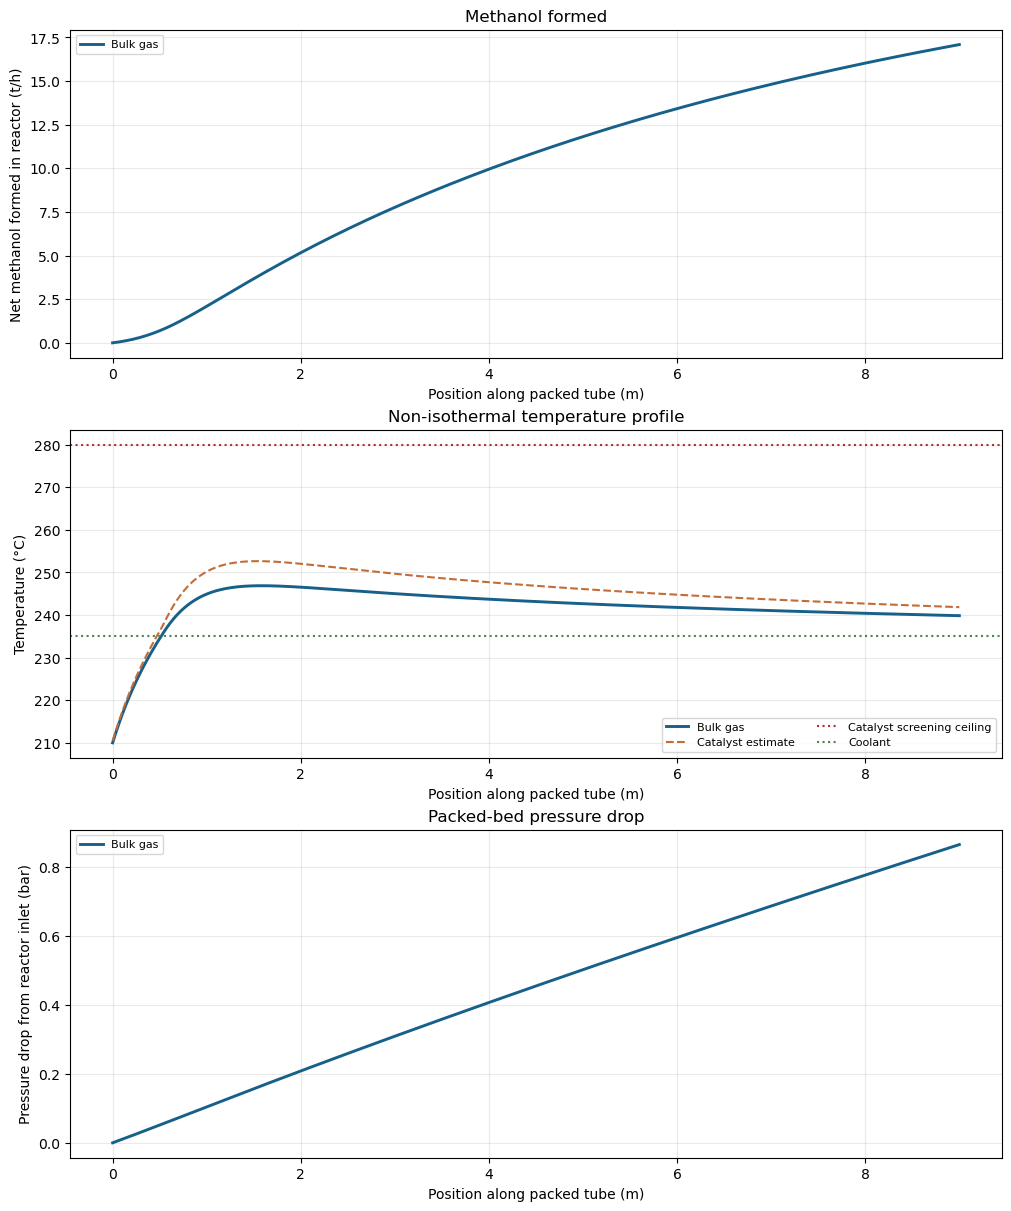

In [8]:
import matplotlib.pyplot as plt
profile = profile_rows(loop_case)
fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)
plot_groups = [
    ("methanol_net_formed_t_h", "Net methanol formed in reactor (t/h)", "Methanol formed"),
    ("temperature_C", "Temperature (°C)", "Non-isothermal temperature profile"),
    ("pressure_drop_bar", "Pressure drop from reactor inlet (bar)", "Packed-bed pressure drop"),
]
for axis, (key, ylabel, title) in zip(axes, plot_groups):
    axis.plot([x["z_m"] for x in profile], [x[key] for x in profile],
              lw=2.1, label="Bulk gas", color="#176089")
    if key == "temperature_C":
        ep = loop_case["engineering"]["profiles"]
        axis.plot([x["z_m"] for x in ep], [x["estimated_tube_center_pellet_max_C"] for x in ep],
                  ls="--", lw=1.5, label="Catalyst estimate", color="#c46c37")
        axis.axhline(REACTOR["catalyst_screen_temperature_C"]-REACTOR["thermal_margin_K"],
                     ls=":", color="#a33", label="Catalyst screening ceiling")
        axis.axhline(CONDITIONS["coolant_temperature_C"], ls=":", color="#47874d", label="Coolant")
    axis.set(title=title, xlabel="Position along packed tube (m)", ylabel=ylabel)
    axis.grid(alpha=.27)
    axis.legend(ncol=2, fontsize=8)
plt.show()

# Heat exchangers H-801, H-803 and H-804: duty and area

**Symbols used below**

| Symbol | Meaning | Unit |
|---|---|---|
| Q | heat duty | W (shown in MW) |
| ṅ | molar flow of a stream | mol/s |
| T_h,in, T_h,out | hot side inlet and outlet temperature | °C |
| T_c,in, T_c,out | cold side inlet and outlet temperature | °C |
| ΔT₁, ΔT₂ | temperature difference at each end of the exchanger (counter-current) | K |
| ΔT_lm | log-mean temperature difference = (ΔT₁ − ΔT₂) / ln(ΔT₁/ΔT₂) | K |
| F | correction factor for a shell-and-tube exchanger that is not purely counter-current | – |
| U | overall heat transfer coefficient | W/(m² K) |
| A | heat transfer area = Q / (U · F · ΔT_lm) | m² |
| Cp | mean heat capacity across the exchanger = Q / (ṅ · \|T_out − T_in\|) | J/(mol K) and kJ/(kg K) |

**How it works.** The duty Q comes from the stream enthalpies in the solved loop (SRK equation of state, so it already accounts for the real heat capacity of the mixture and for condensation). The mean Cp is then worked back from Q. For H-804 some methanol and water condense, so its Cp is an *effective* value that includes latent heat; it is not the gas heat capacity.

**The values in the specification cell (U, F, steam pressure, cooling water temperatures) are placeholders I chose, not data from your notes.** Replace them with your own. A is inversely proportional to U, so a wrong U gives a proportionally wrong area.

In [9]:
# Heat exchanger specifications. ALL VALUES HERE ARE PLACEHOLDER ASSUMPTIONS: replace with your own.
HX = {
    # H-801: hot reactor outlet (807 -> 808) heats raw syngas (801 -> 802). Gas-gas at high pressure.
    "H-801": {"U_W_m2_K": 250.0, "F": 0.9, "min_approach_K": 10.0},
    # H-803: condensing HPS heats the mixed loop feed (805 -> 806). Hot side is isothermal, so F = 1.
    "H-803": {"U_W_m2_K": 400.0, "F": 1.0, "min_approach_K": 10.0, "HPS_pressure_bar_abs": 50.0},
    # H-804: cools reactor outlet (808 -> 809) with cooling water; some methanol and water condense.
    "H-804": {"U_W_m2_K": 500.0, "F": 0.9, "min_approach_K": 5.0,
              "CW_in_C": 25.0, "CW_out_C": 30.0},
}
CP_WATER_J_KG_K = 4180.0   # liquid water, used for the cooling water flow

In [10]:
# Duty and area for H-801, H-803 and H-804, taken from the solved loop (loop_case).
sm = loop_case["summary"]
S = loop_case["streams"]          # name -> (mol/s vector, T in K, P in Pa, phase)

def lmtd(dT1, dT2):
    if dT1 <= 0 or dT2 <= 0:
        raise ValueError(f"Temperature cross (dT1={dT1:.1f} K, dT2={dT2:.1f} K): LMTD not defined. "
                         "Check the utility temperatures or outlet temperatures.")
    if abs(dT1-dT2) < 1e-6*max(dT1, dT2):
        return 0.5*(dT1+dT2)
    return (dT1-dT2)/np.log(dT1/dT2)

def tC(name):  return S[name][1]-273.15              # stream temperature, deg C
def n_dot(name): return float(S[name][0].sum())       # mol/s
def m_dot(name): return float(S[name][0]@MW)/1000.0   # kg/s (MW is in g/mol)

def mean_cp(Q_W, name_in, name_out):
    """Mean Cp = Q / (n_dot * |T_out - T_in|); returns (J/mol/K, kJ/kg/K)."""
    dT = abs(tC(name_out)-tC(name_in))
    cp_mol = abs(Q_W)/(n_dot(name_in)*dT)
    cp_mass = abs(Q_W)/(m_dot(name_in)*dT)/1000.0
    return cp_mol, cp_mass

def hpS_saturation(P_bar):
    """Saturation temperature (deg C) and latent heat (J/kg) of steam at P_bar, from water_saturation()."""
    T = brentq(lambda t: water_saturation(t)["pressure_Pa"]-P_bar*1e5, 373.15, 640.0)
    return T-273.15, water_saturation(T)["latent_heat_J_kg"]

res = {}
warnings = []

# ---- H-801: cold 801 -> 802, hot 807 -> 808
h = HX["H-801"]; Q = sm["H801_duty_MW"]*1e6
r = dict(hot="Stream 807 -> 808", cold="Stream 801 -> 802", Q=Q,
         Th_in=tC("807"), Th_out=tC("808"), Tc_in=tC("801"), Tc_out=tC("802"))
r["dT1"] = r["Th_in"]-r["Tc_out"]; r["dT2"] = r["Th_out"]-r["Tc_in"]
r["cp_cold"] = mean_cp(Q, "801", "802"); r["cp_hot"] = mean_cp(Q, "807", "808")
r["utility"] = ("—", None)
res["H-801"] = r

# ---- H-803: cold 805 -> 806, hot = condensing HPS
h = HX["H-803"]; Q = sm["H803_duty_MW"]*1e6
Tsat, hfg = hpS_saturation(h["HPS_pressure_bar_abs"])
r = dict(hot=f"HPS condensing at {h['HPS_pressure_bar_abs']:g} bar abs", cold="Stream 805 -> 806", Q=Q,
         Th_in=Tsat, Th_out=Tsat, Tc_in=tC("805"), Tc_out=tC("806"))
r["dT1"] = Tsat-r["Tc_out"]; r["dT2"] = Tsat-r["Tc_in"]
r["cp_cold"] = mean_cp(Q, "805", "806"); r["cp_hot"] = None
r["utility"] = ("HPS consumed (t/h)", Q/hfg*3.6)
res["H-803"] = r

# ---- H-804: hot 808 -> 809, cold = cooling water
h = HX["H-804"]; Q = sm["H804_duty_MW"]*1e6
r = dict(hot="Stream 808 -> 809", cold=f"Cooling water {h['CW_in_C']:g} -> {h['CW_out_C']:g} °C", Q=Q,
         Th_in=tC("808"), Th_out=tC("809"), Tc_in=h["CW_in_C"], Tc_out=h["CW_out_C"])
r["dT1"] = r["Th_in"]-r["Tc_out"]; r["dT2"] = r["Th_out"]-r["Tc_in"]
r["cp_cold"] = None; r["cp_hot"] = mean_cp(Q, "808", "809")
r["utility"] = ("Cooling water (t/h)", Q/(CP_WATER_J_KG_K*(h["CW_out_C"]-h["CW_in_C"]))*3.6)
res["H-804"] = r

for name, r in res.items():
    h = HX[name]
    r["dT_lm"] = lmtd(r["dT1"], r["dT2"])
    r["F"] = h["F"]; r["U"] = h["U_W_m2_K"]
    r["A"] = abs(r["Q"])/(r["U"]*r["F"]*r["dT_lm"])
    if min(r["dT1"], r["dT2"]) < h["min_approach_K"]:
        warnings.append(f"{name}: smallest end temperature difference {min(r['dT1'], r['dT2']):.1f} K "
                        f"is below the {h['min_approach_K']:g} K minimum approach.")

def cell(r, key, i):
    v = r[key]
    return None if v is None else v[i]

names = list(res)
rows = [
    ["Hot side", "—"]+[res[n]["hot"] for n in names],
    ["Cold side", "—"]+[res[n]["cold"] for n in names],
    ["Duty, Q", "MW"]+[res[n]["Q"]/1e6 for n in names],
    ["T_h,in", "°C"]+[res[n]["Th_in"] for n in names],
    ["T_h,out", "°C"]+[res[n]["Th_out"] for n in names],
    ["T_c,in", "°C"]+[res[n]["Tc_in"] for n in names],
    ["T_c,out", "°C"]+[res[n]["Tc_out"] for n in names],
    ["ΔT₁ (hot in − cold out)", "K"]+[res[n]["dT1"] for n in names],
    ["ΔT₂ (hot out − cold in)", "K"]+[res[n]["dT2"] for n in names],
    ["ΔT_lm", "K"]+[res[n]["dT_lm"] for n in names],
    ["F (assumed)", "—"]+[res[n]["F"] for n in names],
    ["U (assumed)", "W/(m² K)"]+[res[n]["U"] for n in names],
    ["Area, A", "m²"]+[res[n]["A"] for n in names],
    ["Mean Cp, cold side", "J/(mol K)"]+[cell(res[n], "cp_cold", 0) for n in names],
    ["Mean Cp, cold side", "kJ/(kg K)"]+[cell(res[n], "cp_cold", 1) for n in names],
    ["Mean Cp, hot side", "J/(mol K)"]+[cell(res[n], "cp_hot", 0) for n in names],
    ["Mean Cp, hot side", "kJ/(kg K)"]+[cell(res[n], "cp_hot", 1) for n in names],
    ["Utility flow", "t/h"]+[("— " if res[n]["utility"][1] is None else f"{res[n]['utility'][1]:,.2f}  ({res[n]['utility'][0]})") for n in names],
]
bordered_table("Heat exchanger duty and area (U, F and utility conditions are assumed)", ["Quantity", "Unit"]+names, rows)
for w in warnings:
    display(HTML(f"<p><b>Warning:</b> {html.escape(w)}</p>"))

Quantity,Unit,H-801,H-803,H-804
Hot side,—,Stream 807 -> 808,HPS condensing at 50 bar abs,Stream 808 -> 809
Cold side,—,Stream 801 -> 802,Stream 805 -> 806,Cooling water 25 -> 30 °C
"Duty, Q",MW,2.21748,5.75916,13.09741
"T_h,in",°C,239.84137,263.94048,195.41747
"T_h,out",°C,195.41747,263.94048,32.00000
"T_c,in",°C,40.00000,100.85297,25.00000
"T_c,out",°C,180.00000,210.00000,30.00000
ΔT₁ (hot in − cold out),K,59.84137,53.94048,165.41747
ΔT₂ (hot out − cold in),K,155.41747,163.08751,7.00000
ΔT_lm,K,100.14075,98.65010,50.09150


# Basis, equations and source links

The raw table is **20.384 t/h excluding H₂S**. Specifying H₂S as 0.03 mass% of the inclusive raw total adds 6.117 kg/h, for a raw stream of 20.390117 t/h. The rounded alternative 0.01 mole% is not imposed simultaneously. The ZnO guard is specified at **0.01 ppmv H₂S on the fresh gas**; because fresh sulfur is added continuously and leaves with the purge, H₂S at the mixed reactor inlet can be higher. H₂S is a trace spectator here; sulfur poisoning and guard life are not predicted.

The model integrates the variable **gas temperature, pressure, species flows and heat removed** along the packed tubes. CO + 2H₂ ⇌ CH₃OH, CO₂ + 3H₂ ⇌ CH₃OH + H₂O and CO₂ + H₂ ⇌ CO + H₂O use reversible Bisotti/Graaf rates based on SRK fugacities, with equilibrium constants derived from species Gibbs energies. SRK is used throughout gas equilibrium and the reactor; its use here is supported by the industrial methanol comparison in Bisotti et al. (2022), but unspecified binary interaction coefficients are set to zero. A separate NRTL methanol/water liquid model is used for D-801. Only methanol and water condense by assumption; other species stay in the vapour.

The pellet solves coupled multicomponent diffusion and conduction, including Knudsen diffusion, Darcy flow and an external film. It applies the calculated volume-averaged rate directly, so no extra effectiveness factor is multiplied into the reaction rate. Weisz–Prater and film checks are reported above. Inside-wall/radial-bed, steel-wall, fouling and water-side resistances are summed on an inside-area basis. The boiling-water shell temperature is held at the chosen saturation temperature; **the reacting gas is not isothermal**. The radial centre-line catalyst temperature is an estimate from a one-dimensional closure and is the correct quantity to compare with the chosen 300°C screen minus 20 K margin. The steel conductivity follows the vendor temperature data; 316L and 2 mm wall remain preliminary mechanical assumptions.

The catalyst is modelled at **constant activity**: no ageing, deactivation or poisoning is included. Results therefore represent fresh catalyst only.

Sources used in this notebook:

| Source | What was taken from it |
|---|---|
| [Bisotti et al. (2021), accepted manuscript](https://air.unimi.it/retrieve/dfa8b9a8-5e47-748b-e053-3a05fe0a3a96/IECR%20%282021%29%20invio%20revised.pdf) | Reversible methanol/RWGS kinetic formulation and parameters. |
| [Bisotti et al. (2022), accepted manuscript](https://re.public.polimi.it/bitstream/11311/1217120/1/2022%20-%20I%26ECr%20-%20Fil%2002.pdf) | SRK reactor context and representative bed voidage, pellet size, density and tube geometry. |
| [Graaf et al. (1990)](https://www.sciencedirect.com/science/article/pii/000925099085001T); [Cantera dusty-gas equations](https://cantera.org/stable/cxx/dc/de6/classCantera_1_1DustyGasTransport.html) | Experimental diffusion concern and governing multicomponent pellet transport form. |
| [Hastadi et al. (2024)](https://onlinelibrary.wiley.com/doi/full/10.1002/cjce.25275); [Karakaya & Turnaoglu (2026)](https://aiche.onlinelibrary.wiley.com/doi/full/10.1002/aic.70159); [Sun et al. (2026)](https://www.sciencedirect.com/science/article/pii/S0360319925056484) | Transferred pore fraction/tortuosity, 10 nm pore diameter and pellet thermal conductivity; these are **not** a single certified catalyst. |
| [Wakao & Funazkri (1978)](https://www.sciencedirect.com/science/article/pii/0009250978851203); [Li & Finlayson (1977)](https://faculty.washington.edu/finlayso/HeatTransferReevaluation.pdf) | Gas film and packed-bed wall/radial transfer correlations and applicable Reynolds ranges. |
| [Alleima 316/316L](https://www.alleima.com/en/technical-center/material-datasheets/bar-and-hollow-bar/hollow-bar/sanmac-316316l/); [IAPWS water saturation](https://iapws.org/technical-guidance/release/Supp-sat); [Cooper boiling correlation](https://doi.org/10.1016/B978-0-85295-175-0.50013-8) | Steel conductivity, boiling-water saturation and indicative outside boiling coefficient. |
| [Rahmatmand et al. (2018)](https://mdpi-res.com/d_attachment/catalysts/catalysts-08-00255/article_deploy/catalysts-08-00255.pdf) | 300°C catalyst screening temperature. |

**Design status:** The 6% purge, 4000 tubes, pressure losses and many heat-transfer inputs are engineering assumptions, not an economic optimum. Qualify the catalyst data, mechanical tube design, boiling bundle/circulation and actual separator liquid composition before claiming a final plant design. The pressure entries are **absolute**; 811 and 813 share the D-801 splitter pressure, while compressor discharge 812 is higher. If the methanol target is not met, the notebook reports the shortfall; it does not adjust purge or tube count silently.